# SECOM Dual-Monitoring System  
**Cost-Sensitive Early Warning + Explainable Root-Cause Diagnosis for Semiconductor Fault Detection**

### Project Overview & Business Objective
This project develops a **dual-layer monitoring system** to predict and diagnose defective products in semiconductor manufacturing using the SECOM dataset (UCI Machine Learning Repository).  

**Core business problem**:  
In semiconductor production, the cost of missing a single defect (False Negative) can be **hundreds of times higher** than the cost of a false alarm (False Positive) — leading to scrapped wafers, rework, customer claims, and lost contracts. Defects are extremely rare (~6.6% Fail rate, 1:14 imbalance), yet their impact is catastrophic.  

The goal is to build a system that:  
- **Detects failures early** with high recall to minimize FN cost.
- **Explains root causes** transparently (XAI) to guide fast corrective action.
- **Optimizes total economic cost** (Total Cost of Quality – TCQ). 

### Dataset
- **Source**: SECOM (UCI ML Repository).  
- **Size**: 1567 samples, 590 anonymous sensor features.  
- **Target**: Pass/Fail (converted to 0 = Pass, 1 = Fail).  
- **Imbalance**: ~93.4% Pass, ~6.6% Fail (1:14 ratio).  

### Proposed Solution – Dual-Monitoring Architecture
A two-stage hybrid system combining predictive power and explainability:

**Stage 1 – Early Warning Station (Cost-Sensitive XGBoost)**  
- Hybrid Feature Selection: Boruta (all-relevant) + RFECV (recall-oriented) → reduced from 590 to **13 key features**  
- Hyperparameter tuning: Bayesian Optimization (Optuna)  
- Threshold optimization: Directly minimizes **Total Cost of Quality** (C_FN = 100, C_FP = 1)  
- Focus: High recall + low economic cost

**Stage 2 – Diagnosis Station (Explainable Bayesian Network)**  
- Transforms raw sensor data into **interpretable states** using k-means discretization (Elbow-optimized).  
- Learns causal structure via Hill-Climbing (BIC) → captures dependencies between process variables.  
- Estimates probabilistic relationships through Conditional Probability Tables (CPTs) by using Maximum Likelihood Estimation (MLE).  
- Performs real-time inference (Variable Elimination) to identify **likely root causes when a failure alert is triggered**.  
- Provides **actionable insights**: key contributing sensors, risk uplift, and interpretable failure pathways.

### Key Metrics & Prioritization
- Primary: **Recall (Fail)**, **Geometric Mean (GM)**, **Total Cost of Quality (TCQ)**.
- Secondary: Precision, PR-AUC, F1 (for reference only).  
- Accuracy and ROC-AUC are deprioritized due to severe imbalance.

### Main Results & Business Value
- High recall on minority class (Fail) with optimized economic cost.  
- Transparent root-cause diagnosis: identifies which sensors and states most increase failure risk.  
- Interactive Streamlit dashboard: real-time input → alert + diagnosis.  
- Demonstrates clear economic advantage over traditional models (lower TCQ, faster root-cause resolution).

### Technologies
- Python 3.10+.  
- XGBoost, Optuna, pgmpy, scikit-learn, imbalanced-learn.  
- Visualization: Matplotlib, Seaborn, Plotly, NetworkX.  
- Dashboard: Streamlit.  

**Business Impact**  
- Reduces cost of missed defects through early, high-recall detection.  
- Shortens diagnostic time via automated root-cause insights.  
- Enables condition-based maintenance instead of scheduled checks.  
- Ready for real-world pilot deployment in semiconductor fabs.

**Table of Contents**

- [1. Import Libraries & Setup](#1-import-libraries--setup)
- [2. Load & Merge SECOM Dataset](#2-load--merge-secom-dataset)
- [3. Exploratory Data Analysis & Preprocessing](#3-exploratory-data-analysis--preprocessing)  
  - [3.1 Data Nature: Time-Series or Cross-Sectional?](#31-data-nature-time-series-or-cross-sectional)  
  - [3.2 Standardizing Target Variable](#32-standardizing-target-variable)  
  - [3.3 Removing Constant Features](#33-removing-constant-features)  
  - [3.4 Missing Values Analysis](#34-missing-values-analysis)  
  - [3.5 KNN-Based Imputation](#35-knn-based-imputation)  
  - [3.6 Class Imbalance Visualization](#36-class-imbalance-visualization)  
  - [3.7 Outlier Analysis](#37-outlier-analysis)  
  - [3.8 Correlation Analysis](#38-correlation-analysis)  

- [4. Metrics Definition & Prioritization](#4-metrics-definition--prioritization)  
- [5. Hybrid Feature Selection](#5-hybrid-feature-selection)
- [6. Stage 1: Early Warning Station](#6-stage-1-early-warning-station)  
- [7. Stage 2: Diagnosis Station](#7-stage-2-diagnosis-station)
  - [7.1 Discretisation for Bayesian Network](#71-discretisation-for-bayesian-network)  
  - [7.2 Causal Structure Learning](#72-causal-structure-learning)  
  - [7.3 Parameter Learning & Inference](#73-parameter-learning--inference)    
- [8. Web App Demo](#8-web-app-demo)  

## 1. Import Libraries & Setup

In [1]:
# SECOM Yield Prediction – Fault Detection
# Import & Environment Setup

# 1. Standard Libraries
import os
import random
import warnings
from io import BytesIO

# 2. Core Numeric & Data
import numpy as np
import pandas as pd

# 3. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# 4. Data Loading
import requests
from ucimlrepo import fetch_ucirepo

# 5. Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from scipy.stats.mstats import winsorize

# 6. Imbalanced Learning
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 7. Modeling
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

# 8. Model Selection & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, auc, average_precision_score, make_scorer 
)

from imblearn.metrics import geometric_mean_score

# 9. Hyperparameter Tuning
import optuna

SEED = 42

# Fix randomness
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Suppress warnings
warnings.filterwarnings("ignore")

# External configs
optuna.logging.set_verbosity(optuna.logging.WARNING)
xgb.set_config(verbosity=0)

c:\Users\tt286\anaconda3\envs\secom\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load & Merge SECOM Dataset

**Objective**  
Load and merge the SECOM dataset into a unified dataframe for downstream analysis.
 
**Dataset Overview**:  
- 1567 wafer runs.  
- 590 anonymized sensor features.  
- Target: Pass (-1) / Fail (1) → mapped to binary (0/1). 
- Severe imbalance (~6.6% Fail, ~1:14).

**Reproducibility**  
- Data fetched directly from source (no manual download).

**Output**  
- Clean dataframe ready for EDA and modeling.

In [2]:
def secom_data_request():
    train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
    labels_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"
    
    # Load training data
    response_data = requests.get(train_url)
    data = pd.read_csv(BytesIO(response_data.content), sep=" ", header=None)
    
    # Load labels data
    response_labels = requests.get(labels_url)
    labels = pd.read_csv(BytesIO(response_labels.content), sep=" ", header=None)
    
    # Merger datasets by index
    df = pd.merge(data, labels, left_index=True, right_index=True, how='inner')
    
    # Rename comlumns for clarity
    df.rename(columns={'0_x':'0','1_x':'1','0_y':'Pass/Fail','1_y':'Time'}, inplace = True)
    
    return df

# Execute data loading
df = secom_data_request()

# Basic dataset info
print("SECOM dataset after loading and merging:")
print(f"- Number of samples: {df.shape[0]}")
print(f"- Number of columns: {df.shape[1]}")

df.head()

SECOM dataset after loading and merging:
- Number of samples: 1567
- Number of columns: 592


,0,1,2,3,4,5,6,7,8,9,...,582,583,584,585,586,587,588,589,Pass/Fail,Time
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,19/07/2008 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,19/07/2008 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,19/07/2008 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 15:22:00


## 3. Exploratory Data Analysis & Preprocessing

**Objective**  
Conduct comprehensive EDA to understand data characteristics, identify potential issues (missing values, imbalance, outliers, correlation), and design a robust preprocessing pipeline that ensures **reliable, cost-sensitive, and interpretable modeling**.

### Key Challenges Identified
- **Severe class imbalance** (~6.6% Fail, ~1:14 ratio) → high risk of costly False Negatives  
- **High-dimensional and noisy data** (590 anonymous sensor features) → prone to noise domination  
- **~5.5% missing values** (41,136 entries) with **structured patterns** (not MCAR)  
- **Widespread outliers** (~99% of rows affected) but no strong bias toward Fail class  
- **Weak linear relationships** → predictive signal is sparse and distributed  

### Preprocessing Strategy (Data-Driven Decisions)
- Treat dataset as **cross-sectional** (not time-series)  
- Remove constant and high-missing features to reduce noise  
- Apply **KNN Imputation** (leveraging feature similarity) instead of mean/median  
- **Preserve outliers** as they may contain rare failure signals  
- Use **RobustScaler** to mitigate the impact of extreme values  
- Perform **stratified train-test split** to maintain class distribution  

### Key Takeaways & Business Implications
- Failure signals are **weak and distributed across many features** → requires hybrid feature selection and powerful models (e.g., tree-based)  
- Accuracy/F1 are insufficient → prioritize **Recall and Total Cost of Quality (TCQ)**  
- Structured missingness → **multivariate imputation is essential**  
- Outliers are not purely random noise → removing them may discard economically critical information  

**These insights directly shape the design of the Dual-Monitoring System:**
- **Stage 1 (Early Warning):** prioritize **high recall and cost-sensitive learning** to minimize missed failures  
- **Stage 2 (Diagnosis):** use an **interpretable model (Bayesian Network)** for root-cause analysis

### 3.1 Data Nature: Time-Series or Cross-Sectional?

**Objective**  
Assess whether the SECOM dataset contains temporal dependencies or can be treated as independent observations.

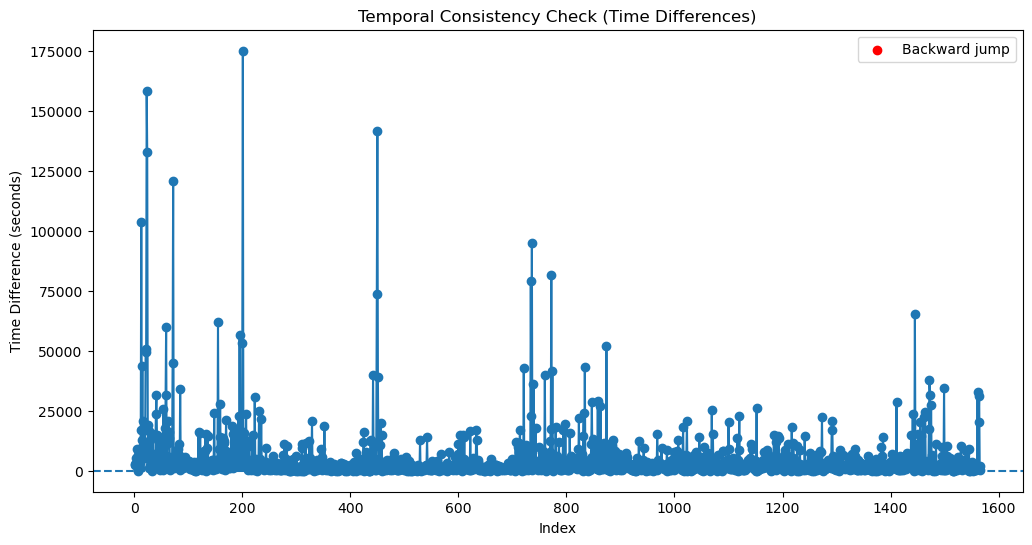

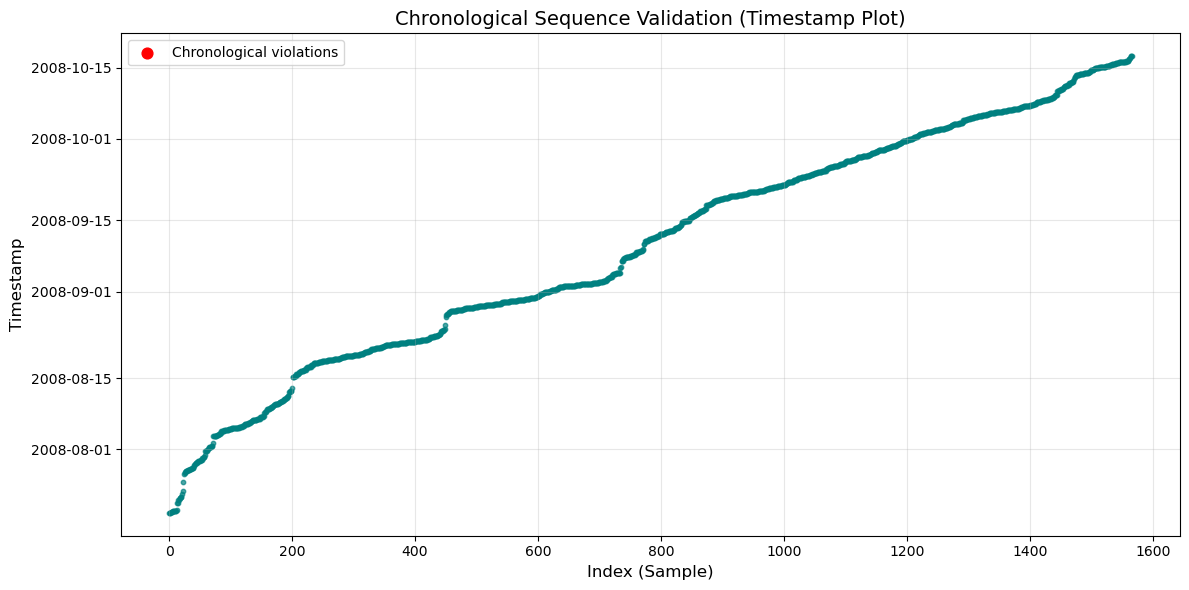

In [3]:
# 1. Time Gap Between Consecutive Observations

# Check temporal ordering to determine data nature
df['Time'] = pd.to_datetime(df['Time'], dayfirst=True, errors='coerce')

# Compute time differences between consecutive observations
df['Time_Diff'] = df['Time'].diff().dt.total_seconds()

# Plot time gaps between observations
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Time_Diff'], marker='o')

# Highlight backward time jumps (violations of chronological orders)
violations = df[df['Time_Diff'] < 0]
plt.scatter(violations.index, violations['Time_Diff'], color='red', label='Backward jump')

# Reference line at zero
plt.axhline(0, linestyle='--')
plt.xlabel("Index")
plt.ylabel("Time Difference (seconds)")
plt.title("Temporal Consistency Check (Time Differences)")
plt.legend()
plt.show()


# 2. Plot timestamps to visually inspect chronological order
plt.figure(figsize=(12, 6))
plt.scatter(df.index, df['Time'], s=10, color='teal', alpha=0.7)

# Highlight violations (backward time jumps)
plt.scatter(violations.index, violations['Time'], color='red', s=60, label='Chronological violations')

plt.title("Chronological Sequence Validation (Timestamp Plot)", fontsize=14)
plt.xlabel("Index (Sample)", fontsize=12)
plt.ylabel("Timestamp", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Remove temporary columns after analysis
df.drop(columns=['Time_Diff', 'Time'], inplace=True, errors='ignore')

**Key Insight**
- Temporal inconsistencies (backward jumps and irregular intervals) invalidate any time-series assumptions  
- No reliable sequential dependency exists between observations  
- Each sample represents an independent manufacturing run rather than a continuous process  

-> Treating the dataset as time-series would introduce misleading patterns and degrade model reliability  

**Decision**
- The dataset is modeled as **cross-sectional**
- All downstream modeling focuses on **sensor states at inspection time**, not temporal dynamics

In [4]:
# 3. Standardizing Column Names & Data Types
# Convert column names to string to avoid issues in modeling
df.columns = df.columns.astype(str)

# Check final data types
print("\nData types after standardization:")
print(df.dtypes.unique())

# Summary statistics
print("\nDataset summary statistics:")
display(df.describe().round(2))


Data types after standardization:
[dtype('float64') dtype('int64')]

Dataset summary statistics:


,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.00,1560.00,1553.00,1553.00,1553.00,1553.0,1553.00,1558.00,1565.00,1565.00,...,618.00,1566.00,1566.00,1566.0,1566.00,1566.00,1566.00,1566.00,1566.00,1567.00
mean,3014.45,2495.85,2200.55,1396.38,4.20,100.0,101.11,0.12,1.46,-0.00,...,97.93,0.50,0.02,0.0,3.07,0.02,0.02,0.01,99.67,-0.87
std,73.62,80.41,29.51,441.69,56.36,0.0,6.24,0.01,0.07,0.02,...,87.52,0.00,0.02,0.0,3.58,0.01,0.01,0.00,93.89,0.50
min,2743.24,2158.75,2060.66,0.00,0.68,100.0,82.13,0.00,1.19,-0.05,...,0.00,0.48,0.01,0.0,1.20,-0.02,0.00,0.00,0.00,-1.00
25%,2966.26,2452.25,2181.04,1081.88,1.02,100.0,97.92,0.12,1.41,-0.01,...,46.18,0.50,0.01,0.0,2.31,0.01,0.01,0.00,44.37,-1.00
50%,3011.49,2499.40,2201.07,1285.21,1.32,100.0,101.51,0.12,1.46,-0.00,...,72.29,0.50,0.01,0.0,2.76,0.02,0.01,0.00,71.90,-1.00
75%,3056.65,2538.82,2218.06,1591.22,1.53,100.0,104.59,0.12,1.52,0.01,...,116.54,0.50,0.02,0.0,3.30,0.03,0.02,0.01,114.75,-1.00
max,3356.35,2846.44,2315.27,3715.04,1114.54,100.0,129.25,0.13,1.66,0.07,...,737.30,0.51,0.48,0.1,99.30,0.10,0.08,0.03,737.30,1.00


### 3.2 Standardizing Target Variable
**Objective**  
Standardize the target variable to ensure compatibility with machine learning models and improve interpretability.

- Convert **-1 → 0 (Pass)**  
- Keep **1 → 1 (Fail)**  
- Cast target to **categorical type**

**Rationale**
- Most ML libraries (e.g., XGBoost, scikit-learn) expect binary targets in **0/1 format**  
- Improves clarity:  
  - **0 = Pass (non-defective)**  
  - **1 = Fail (defective)**  
- Categorical type helps prevent unintended numerical operations and reduces memory usage  


In [5]:
# 3.2 Standardizing Target Variable (Pass/Fail)
print("Before Standardizing:")
print(df['Pass/Fail'].value_counts())

# Convert -1 → 0 (Pass), hold 1 (Fail)
df['Pass/Fail'] = df['Pass/Fail'].replace(-1, 0)

# Convert to categorical data to save the memory
df['Pass/Fail'].astype('category')

print("\nAfter Standardizing:")
print(df['Pass/Fail'].value_counts())
print("\nTarget Data Types:", df['Pass/Fail'].dtype)

Before Standardizing:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

After Standardizing:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64

Target Data Types: int64


### 3.3 Removing Constant Features

**Objective**  
Remove features with zero or near-zero variance to reduce noise and improve model efficiency.

- Eliminate features with **zero variance (constant features)**  
- Optionally consider near-constant features with extremely low variance  

**Rationale**
- Constant features contain **no discriminative information** for Pass/Fail classification  
- They unnecessarily increase dimensionality and computational cost  
- In the SECOM dataset, constant features show a **non-random pattern**, often clustered toward the end of the feature space  
- This may reflect **inactive sensors, redundant measurements, or system defaults** in semiconductor manufacturing  

In [6]:
def find_constant_features(df):
    """
    Identify all features with zero variance (constant features).
    Returns a DataFrame containing only constant columns.
    """
    constant_cols = [col for col in df.columns if df[col].std() == 0]
    return df[constant_cols]

# Identify constant columns (exclude target variable)
constant_columns = find_constant_features(df.drop('Pass/Fail', axis=1))

# Summary statistics
num_constants = len(constant_columns.columns)
total_features = len(df.columns) - 1  # Exclude target variable
percent_constants = (num_constants / total_features) * 100

print(f"Total constant features: {num_constants}/{total_features} ({percent_constants:.2f}%)")

Total constant features: 116/590 (19.66%)


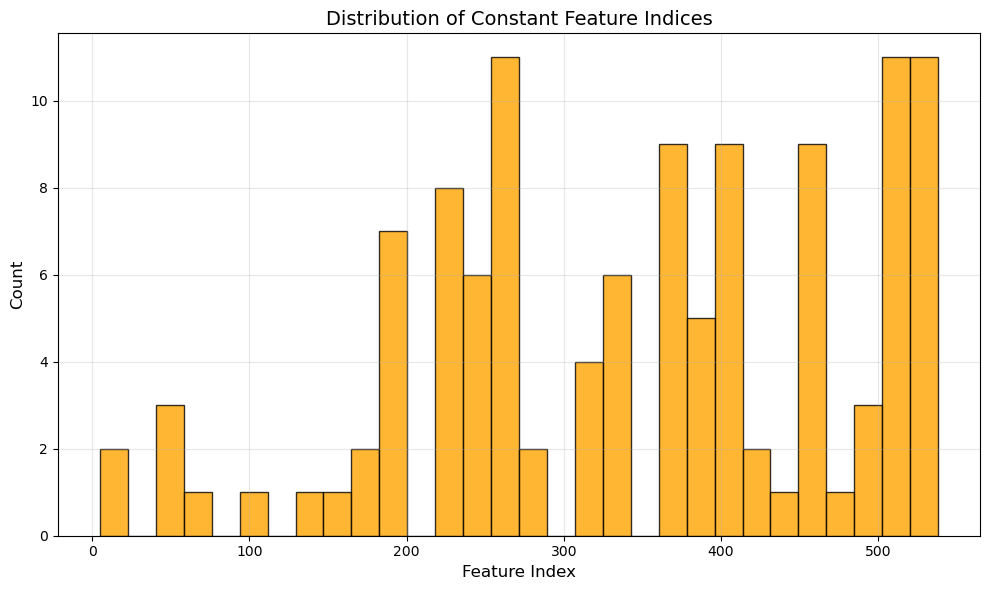

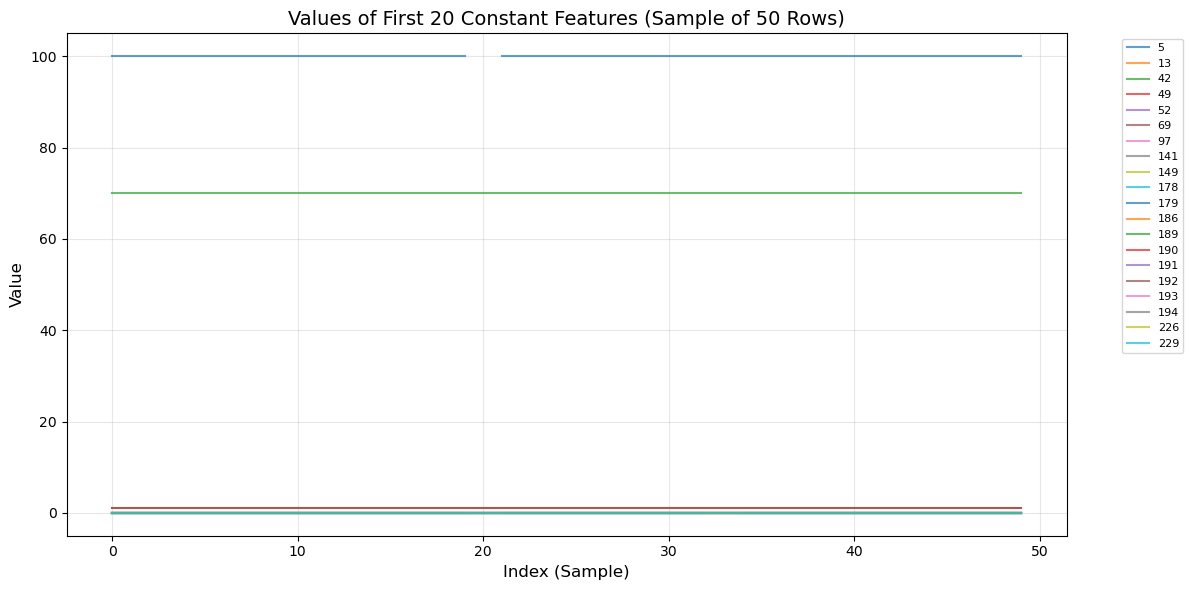

In [7]:
# Visualize distribution of constant feature indices
if num_constants > 0:
    constant_indices = [int(col) for col in constant_columns.columns if col.isdigit()]
    
    plt.figure(figsize=(10, 6))
    plt.hist(constant_indices, bins=30, color='orange', edgecolor='black', alpha=0.8)
    plt.title("Distribution of Constant Feature Indices", fontsize=14)
    plt.xlabel("Feature Index", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Example: visualize first 20 constant features (first 50 samples)
    if num_constants >= 20:
        plt.figure(figsize=(12, 6))
        for col in constant_columns.columns[:20]:
            plt.plot(constant_columns.index[:50], constant_columns[col][:50], label=col, alpha=0.7)
        
        plt.title("Values of First 20 Constant Features (Sample of 50 Rows)", fontsize=14)
        plt.xlabel("Index (Sample)", fontsize=12)
        plt.ylabel("Value", fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [8]:
# Remove constant columns
df = df.drop(columns=constant_columns.columns)

print(f"\nAfter removing constant columns:")
print(f"- The number of remaining columns: {df.shape[1]} (reduce {num_constants} columns)")
print(f"- The number of current missing columns: {df.isnull().sum().sum()}")


After removing constant columns:
- The number of remaining columns: 475 (reduce 116 columns)
- The number of current missing columns: 41136


**Key Insights**

- Constant features account for ~19.66% (116/590), and their removal significantly reduces noise and dimensionality.  

- These features are not randomly distributed but concentrated toward the end of the dataset, suggesting the presence of inactive or redundant sensors, which is common in semiconductor manufacturing systems.

- **Business insight:** Early removal of non-informative features allows the model to focus on meaningful signals, leading to improved predictive performance and reduced computational cost.

### 3.4 Missing Values Analysis

**Objective**  
Analyze missing values to understand their pattern, impact, and mechanism, then decide on the best imputation or removal strategy.

**Key Challenges**  
- ~5.53% missing values (41,136 values) → realistic in sensor data (sensor failure or interruption).  
- Missingness is **not completely random** (structured/block patterns) → cannot safely drop rows.  
- Potential MAR or MNAR mechanism → multivariate imputation required (e.g., KNNImputer).  

**Analysis Strategy**  
1. Visualize missingness per row & per column → identify heavy-missing features.  
2. Set threshold to drop very sparse features (reduce noise & computation).  
3. Investigate remaining missing pattern using missingno, clustering, and statistical tests.  
4. Check bias towards Fail class (critical for cost-sensitive modeling).  

Total missing values: 41136
Missing percentage: 5.53 %



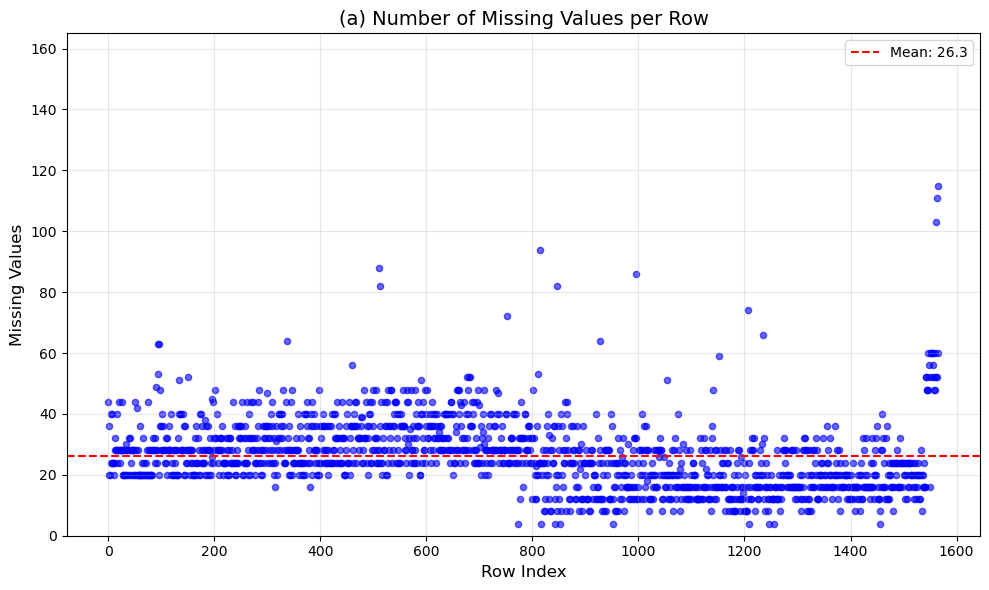

Missing per row → Min: 4 | Max: 115 | Mean: 26.3


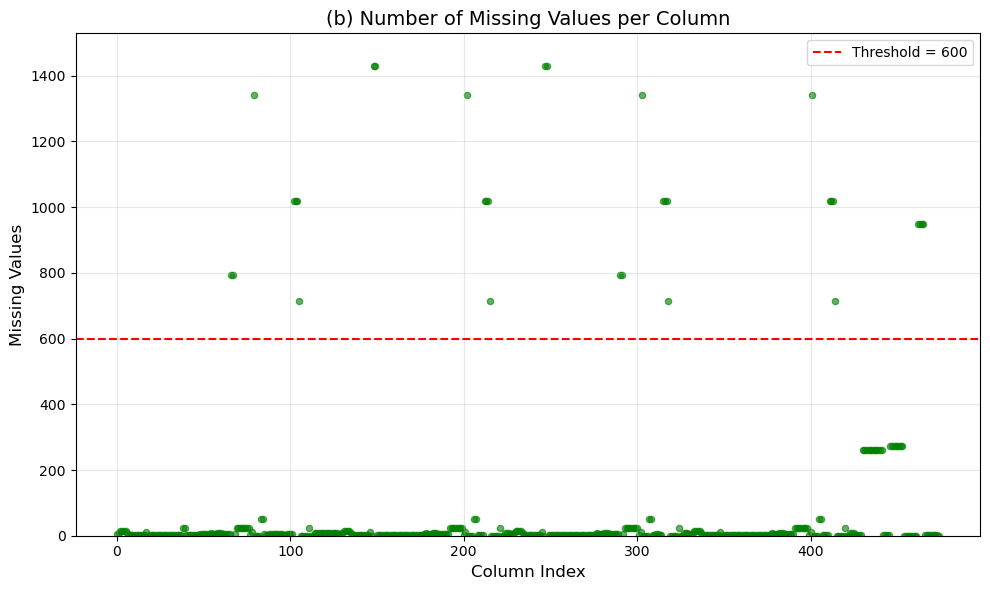

Missing per column → Min: 0 | Max: 1429 | Mean: 86.6


In [9]:
# 3.4.1 Drop Features with Heavy Missing Values

print("Total missing values:", df.isnull().sum().sum())
print("Missing percentage:", round((df.isnull().sum().sum() / df.size) * 100, 2), "%\n")

# (a) Missing values per row
missing_per_row = df.isnull().sum(axis=1)

plt.figure(figsize=(10, 6))
plt.scatter(range(len(missing_per_row)), missing_per_row, s=20, alpha=0.6, color='blue')
plt.axhline(y=missing_per_row.mean(), color='red', linestyle='--', label=f'Mean: {missing_per_row.mean():.1f}')
plt.title("(a) Number of Missing Values per Row", fontsize=14)
plt.xlabel("Row Index", fontsize=12)
plt.ylabel("Missing Values", fontsize=12)
plt.ylim(0, missing_per_row.max() + 50)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Missing per row → Min: {missing_per_row.min()} | Max: {missing_per_row.max()} | Mean: {missing_per_row.mean():.1f}")

# (b) Missing values per column
missing_per_col = df.isnull().sum()

plt.figure(figsize=(10, 6))
plt.scatter(range(len(missing_per_col)), missing_per_col, s=20, alpha=0.6, color='green')
plt.axhline(y=600, color='red', linestyle='--', label='Threshold = 600')
plt.title("(b) Number of Missing Values per Column", fontsize=14)
plt.xlabel("Column Index", fontsize=12)
plt.ylabel("Missing Values", fontsize=12)
plt.ylim(0, missing_per_col.max() + 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Missing per column → Min: {missing_per_col.min()} | Max: {missing_per_col.max()} | Mean: {missing_per_col.mean():.1f}")

**Key Insight**
- High-missing columns (>600) are mostly noise → safe to remove.
- Missing per row is fairly uniform → no single batch with extreme missingness.

In [10]:
# Drop columns with >600 missing values
def drop_high_missing(df, threshold=600):
    """Drop columns with missing values exceeding the given threshold."""
    high_missing_cols = [col for col in df.columns if df[col].isnull().sum() > threshold]
    print(f"Dropping {len(high_missing_cols)} columns with > {threshold} missing values.")
    return df.drop(columns=high_missing_cols)

df = drop_high_missing(df)

# Verify after removal
df_nulls = [col for col in df.columns if df[col].isnull().sum() > 0]
max_missing_after = df[df_nulls].isnull().sum().max()
max_missing_pct = round((max_missing_after / len(df)) * 100, 2)

print(f"\nAfter removal:")
print(f"  - Max missing in any column: {max_missing_after} ({max_missing_pct}%)")
print(f"  - Total columns remaining: {df.shape[1]}")

Dropping 32 columns with > 600 missing values.

After removal:
  - Max missing in any column: 273 (17.42%)
  - Total columns remaining: 443


**Key Insight**
- Removing heavy-missing columns reduces noise and computation time significantly.
- Remaining missingness (~17.42% max in worst column) is manageable with imputation.

### Analyze Remaining Missing Data Patterns

**Objective**  
Determine the missingness mechanism (MCAR, MAR, MNAR) to choose the best imputation strategy.

**Why it matters**  
- If MCAR → simple imputation or row removal is safe.  
- If MAR/MNAR (structured/block pattern) → multivariate imputation (KNN/Iterative) is necessary.

**Steps**  
1. Visualize missingness map (missingno)  
2. Hierarchical clustering on missingness matrix → detect structured patterns  
3. Elbow method to find optimal number of missingness clusters  
4. Reorder missingness map by clusters  
5. Check missingness bias towards Fail class (critical for cost-sensitive modeling)

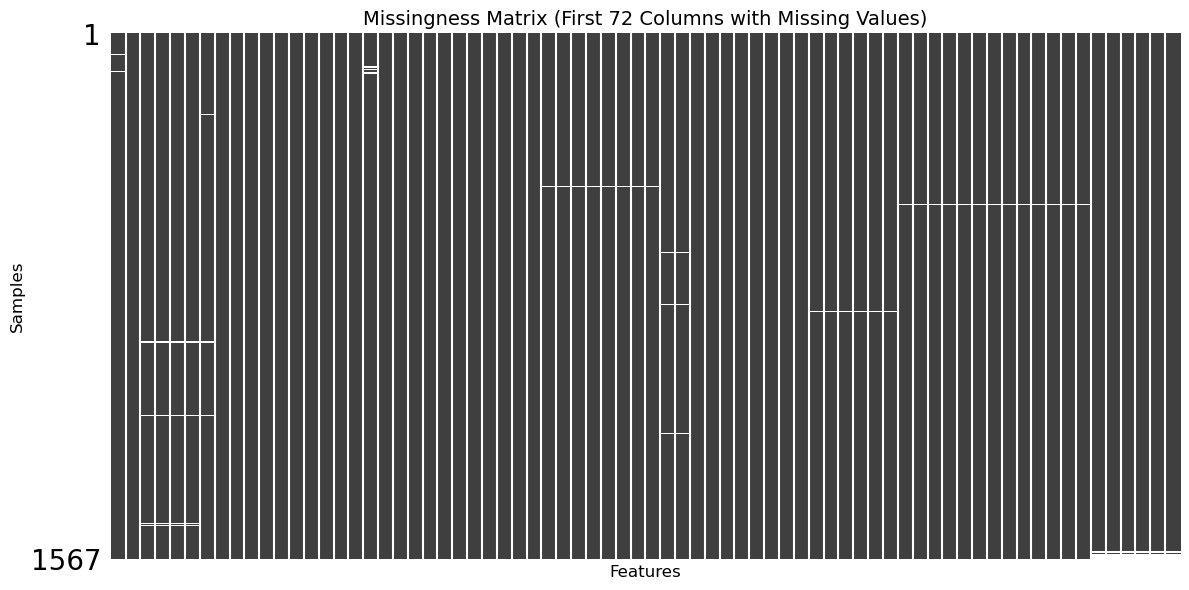

In [11]:
# I. Visualize Missingness Pattern

# Missingness matrix for columns with missing values
msno.matrix(df[df_nulls[:72]], sparkline=False, figsize=(12, 6))
plt.title("Missingness Matrix (First 72 Columns with Missing Values)", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Samples", fontsize=12)
plt.tight_layout()
plt.show()

**Key Insights**

- Missing values appear in **block patterns across groups of features**, indicating they are **not randomly distributed**.  
- This aligns with **sensor system behavior**, where sensors within the same module may fail or lose signal simultaneously.  
- Even after removing high-missing features, the remaining missing values still show **structured similarity across features**.  

**Implications:**  
Given the similarity of missing patterns across observations, **KNNImputer** is appropriate, as it estimates missing values based on **similar samples**.

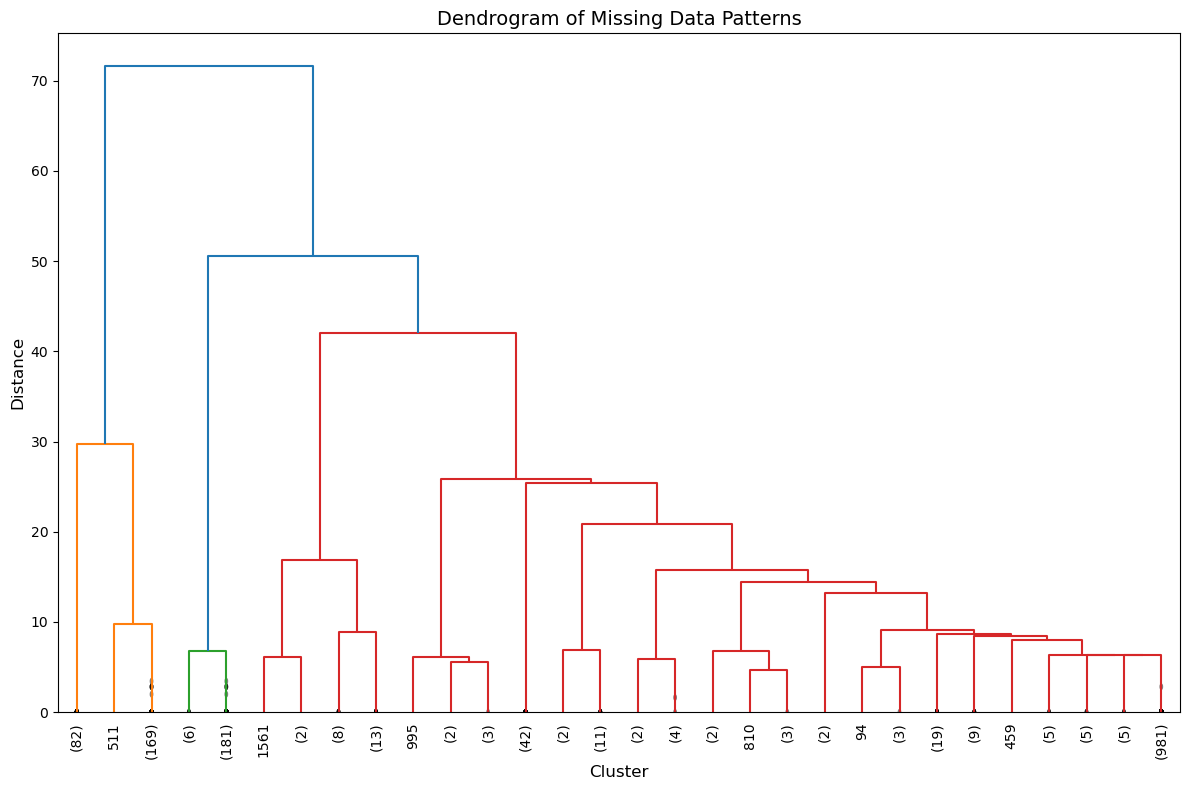

In [12]:
# II. Clustering of Missingness Patterns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# 1. Binary missing matrix (1 = missing, 0 = observed)
missing_matrix = df.drop('Pass/Fail', axis=1).isnull().astype(int)

# 2. Compute pairwise Euclidean distance
distance = pdist(missing_matrix, metric='euclidean')

# 3. Hierarchical clustering with Ward linkage
ward = linkage(distance, method='ward')

# 4. Dendrogram
plt.figure(figsize=(12, 8))
dendrogram(ward, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title("Dendrogram of Missing Data Patterns", fontsize=14)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
plt.show()

**Key Insights**

- Dendrogram shows **distinct clusters of similar missingness patterns**.  
- Most observations belong to a **dominant cluster**, with smaller clusters capturing rarer patterns.  
- Missingness is **structured (not random)**, indicating systematic behavior in the data.  

**Implications:** Suggests the need for **structure-aware imputation methods** (e.g., KNNImputer).

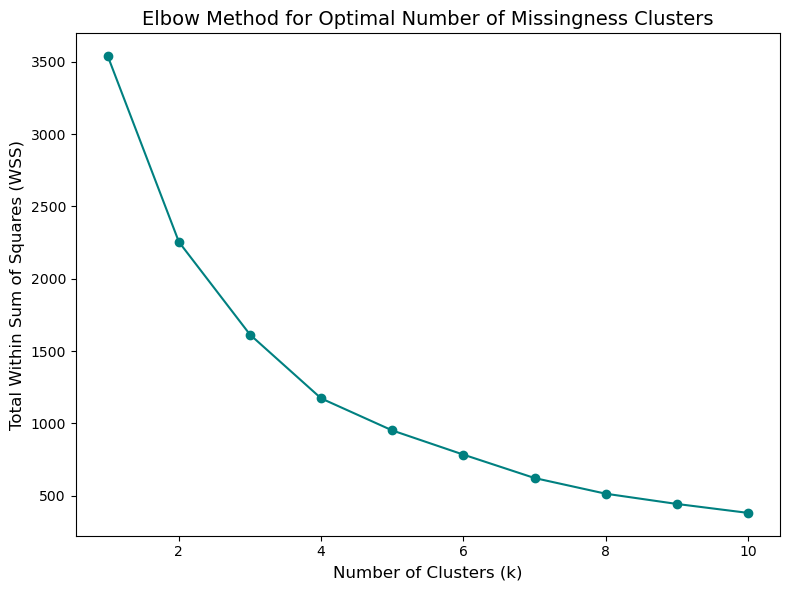

In [13]:
# III. Elbow method to find optimal number of clusters
max_k = 10
wss = []
for k in range(1, max_k + 1):
    clusters = fcluster(ward, t=k, criterion='maxclust')
    total_wss = 0
    for cluster_id in np.unique(clusters):
        cluster_points = missing_matrix.iloc[clusters == cluster_id]
        if len(cluster_points) > 1:
            cluster_dist = pdist(cluster_points, metric='euclidean')
            total_wss += np.sum(cluster_dist ** 2) / (2 * len(cluster_points))
    wss.append(total_wss)

plt.figure(figsize=(8, 6))
plt.plot(range(1, max_k + 1), wss, marker='o', color='teal')
plt.title("Elbow Method for Optimal Number of Missingness Clusters", fontsize=14)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Total Within Sum of Squares (WSS)", fontsize=12)
plt.tight_layout()
plt.show()

**Key Insights**

- The Elbow curve shows a **sharp decrease in WSS up to k = 4**, followed by a slower rate of decline.  
- This indicates diminishing returns in clustering performance beyond this point.  

**Decisions:** Select **k = 4** as the optimal number of clusters.

Fail Rate per Missing Cluster:
                      mean  count
missing_cluster                 
1                7.142857    252
2                7.486631    187
3                0.000000     24
4                6.521739   1104


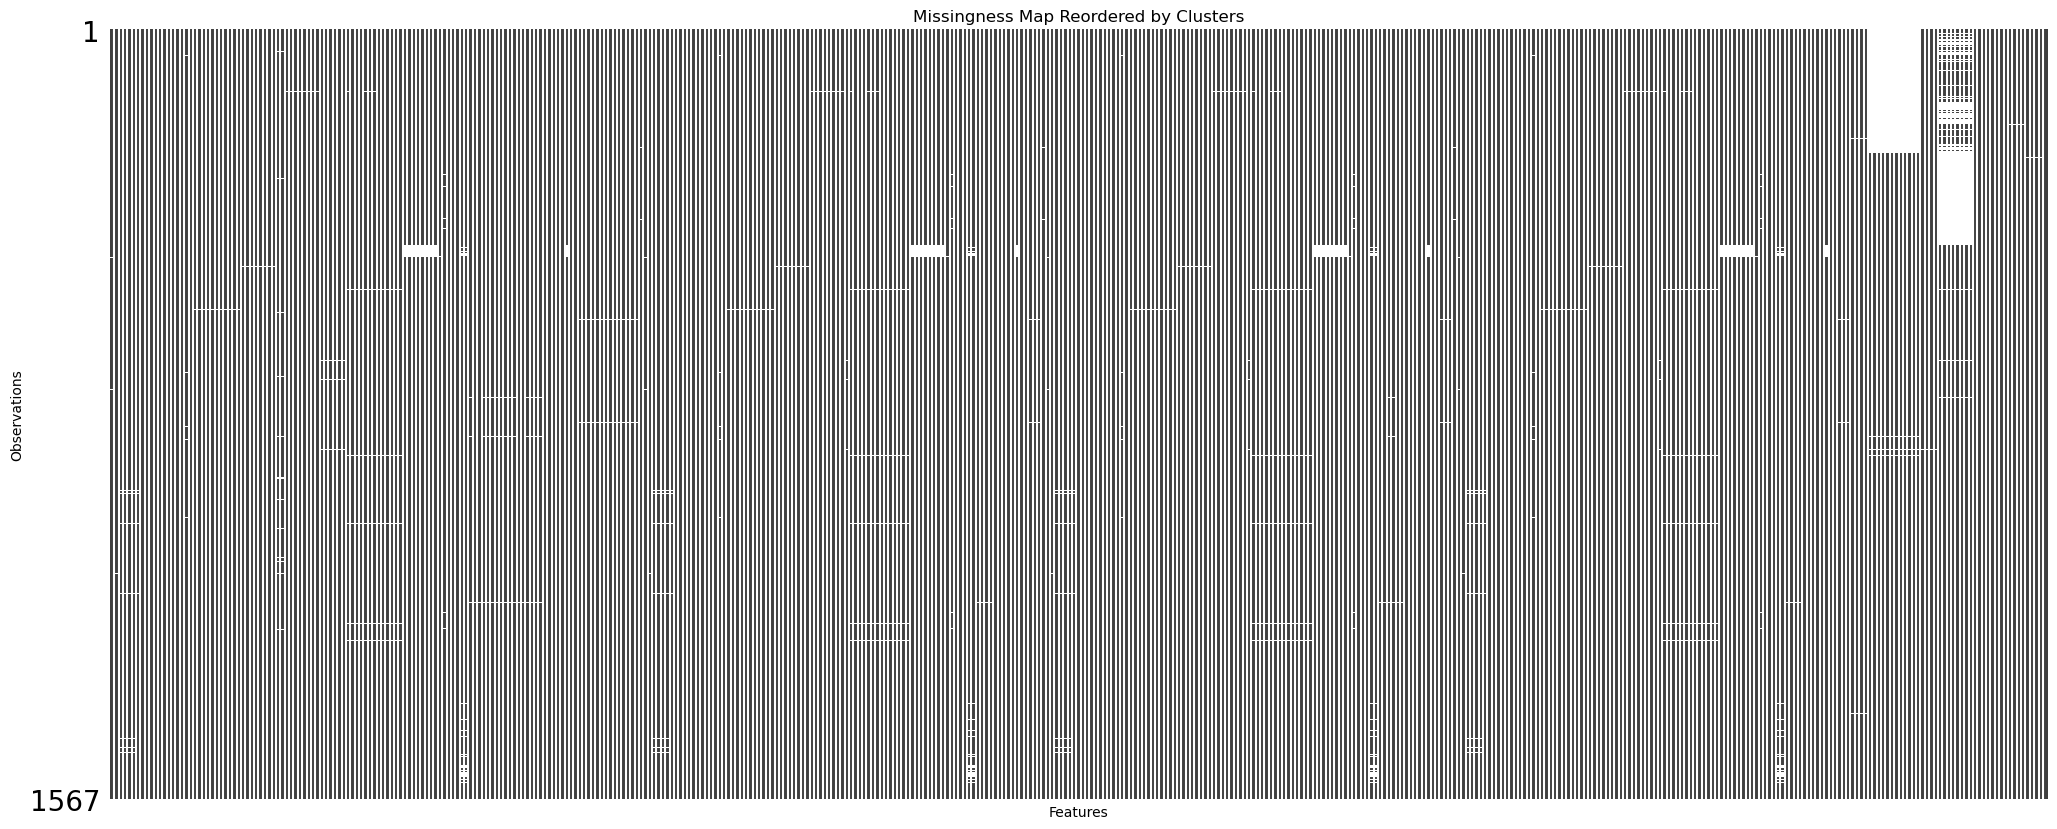

In [14]:
# IV. Missingno matrix by Cluster
# 1. Choose k optimal
optimal_k = 4
clusters = fcluster(ward, t=optimal_k, criterion='maxclust')
df['missing_cluster'] = clusters

# 2. Analyze Fail rate by clusters
cluster_fail_rate = df.groupby('missing_cluster')['Pass/Fail'].agg(['mean', 'count'])
cluster_fail_rate['mean'] = cluster_fail_rate['mean'] * 100  # % Fail
print("Fail Rate per Missing Cluster:\n", cluster_fail_rate)

# 3. Reorder missingno matrix by clusters
sorted_idx = np.argsort(clusters)
msno.matrix(df.drop('Pass/Fail', axis=1).iloc[sorted_idx], sparkline=False)
plt.title('Missingness Map Reordered by Clusters')
plt.xlabel('Features')
plt.ylabel('Observations')
plt.show()

**Key Insights**
- Dendrogram shows **clusters of features with similar missingness patterns**, indicating structured (not independent) missing values.  
- Suggests **simultaneous sensor/module failures**, common in manufacturing systems.  

**Implications:**  
- Missingness is **not random** → use **multivariate imputation** (e.g., KNNImputer).  
- Engineers should **investigate affected modules/stages** to reduce missing data at the source.

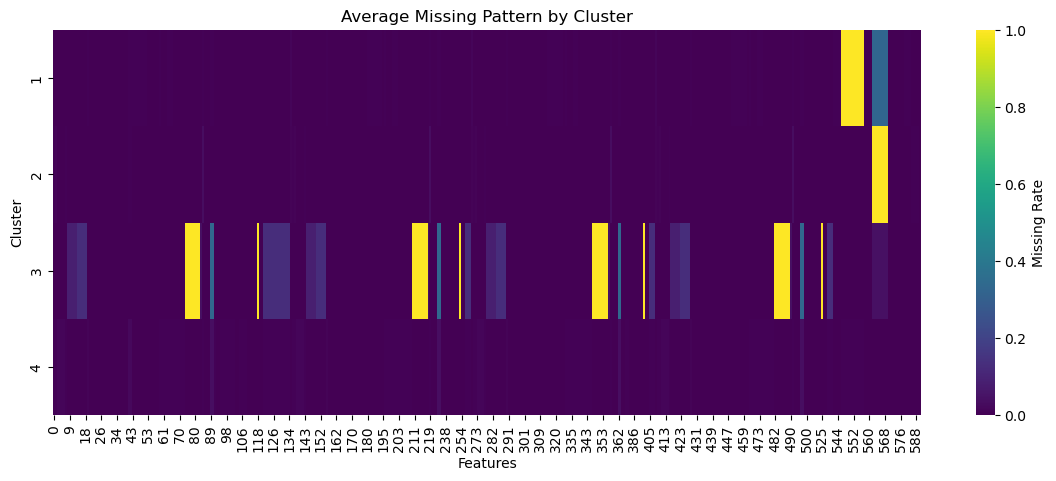

In [15]:
# V. Average Missing Pattern by Cluster
missing_matrix = df.drop('Pass/Fail', axis=1).isnull()

cluster_missing = missing_matrix.groupby(df['missing_cluster']).mean()

plt.figure(figsize=(14,5))

sns.heatmap(
    cluster_missing,
    cmap='viridis',
    cbar_kws={'label': 'Missing Rate'}
)

plt.title('Average Missing Pattern by Cluster')
plt.xlabel('Features')
plt.ylabel('Cluster')

plt.show()

**Key Insights**
- The heatmap provides **clear visual confirmation** of previously identified missingness patterns.  
- Clusters 1 & 2 show **minimal missingness overall**, with small **localized block patterns**.  
- Cluster 3 exhibits **pronounced block missingness**, suggesting potential **data collection issues or measurement errors**.  
- Cluster 4 shows **scattered missingness**, with no strong concentration.  

**Implications:** Reinforces that missingness is **structured and cluster-dependent**, supporting the use of **multivariate imputation methods**.

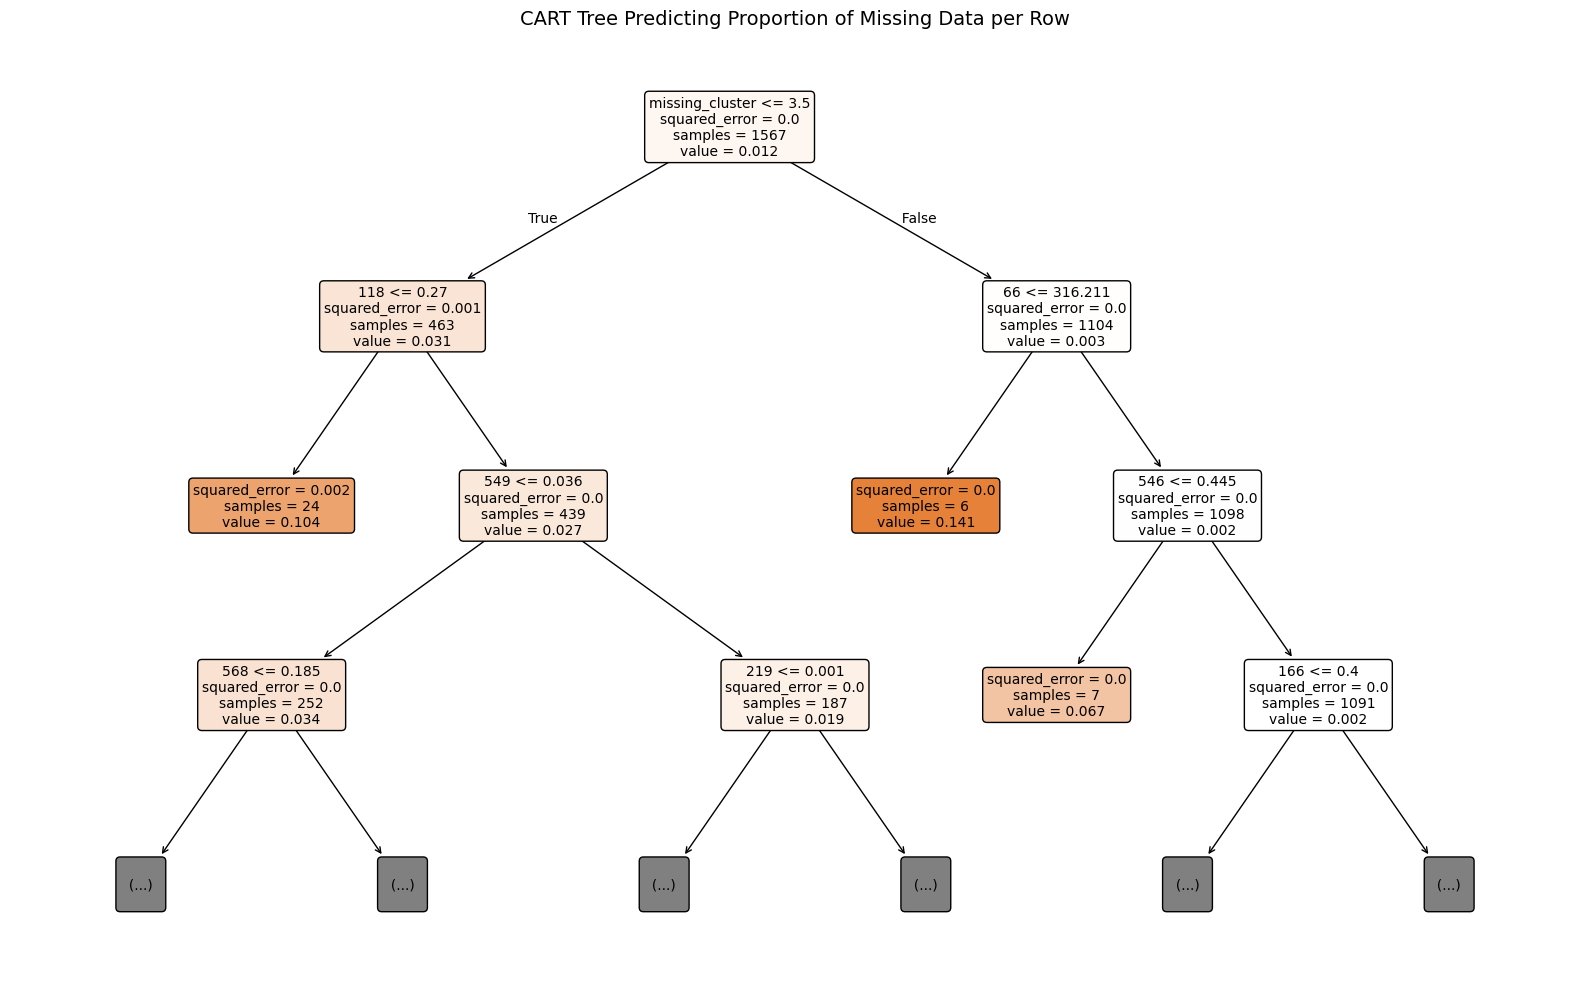

Top 10 features influencing missing proportion:
missing_cluster    0.4307
118                0.2264
66                 0.1934
546                0.0493
549                0.0406
166                0.0318
568                0.0271
219                0.0007
3                  0.0000
4                  0.0000
dtype: float64


In [16]:
# VI. CART Analysis on Missing Data Proportion

from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Calculate proportion of missing per row (target for CART)
df_temp = df.drop('Pass/Fail', axis=1).copy()
df_temp['missing_prop'] = df_temp.isnull().mean(axis=1)  # % missing per row

# 2. Prepare features
X_cart = df_temp.drop('missing_prop', axis=1)
y_cart = df_temp['missing_prop']

# 3. Fit simple CART (Regression Tree)
cart_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=30,
    random_state=42
)
cart_model.fit(X_cart.fillna(0), y_cart)

# 4. Plot the tree
plt.figure(figsize=(16, 10))
plot_tree(cart_model, feature_names=X_cart.columns, filled=True, 
          rounded=True, fontsize=10, max_depth=3)
plt.title("CART Tree Predicting Proportion of Missing Data per Row", fontsize=14)
plt.tight_layout()
plt.show()

# 5. Feature importance from CART
importance = pd.Series(cart_model.feature_importances_, index=X_cart.columns).sort_values(ascending=False)
print("Top 10 features influencing missing proportion:")
print(importance.head(10).round(4))

**Key Insights**
- CART confirms **strong structured missingness**, with root splits driven by `missing_cluster`.  
- Features such as **213, 340, 550, 546** are key predictors of high missingness.  
- Some leaf nodes show **elevated missing proportions (0.104–0.141)**, indicating specific sample groups (e.g., system issues or particular production lots).

**Implications**
- Missingness is **not random** → apply **multivariate imputation** (KNN/Iterative) to preserve structure.  
- Engineers should **investigate feature conditions/splits** (e.g., Feature 213 ≤ 0.002) to identify root causes (tool setup, calibration).  
- Avoid **complete-case analysis** to prevent loss of valuable data.

In [17]:
# VII. Check bias Fail: Mean missing per row by class
df_temp = df.copy()
df_temp['missing_count'] = df_temp.isnull().sum(axis=1)
missing_by_class = df_temp.groupby('Pass/Fail')['missing_count'].mean()
print("Mean missing per row by class:\n", missing_by_class)

Mean missing per row by class:
 Pass/Fail
0    5.147642
1    4.586538
Name: missing_count, dtype: float64


**Key Insights**
- After removing high-missing features, the average missingness per row differs by ~12% between Pass and Fail.  
- No strong evidence that Fail samples have systematically higher missingness.  
- Given the low Fail rate (~6.6%), this difference is likely **random variation**, not a statistically meaningful pattern.  

**Implications:** Missingness is **not strongly correlated with the target**, reducing the risk of bias in modeling.

In [18]:
# VIII. Mann-Whitney U test
from scipy.stats import mannwhitneyu

# Create two groups
missing_pass = df_temp[df_temp['Pass/Fail'] == 0]['missing_count']
missing_fail = df_temp[df_temp['Pass/Fail'] == 1]['missing_count']

# Mann-Whitney U test (non-parametric, suitable for count/skewed data)
stat, p_value = mannwhitneyu(missing_pass, missing_fail, alternative='two-sided')

print(f"Mann-Whitney U test:")
print(f"Statistic: {stat:.2f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ The difference in mean missing values between Pass and Fail is statistically significant (p < 0.05)")
else:
    print("→ The difference in mean missing values between Pass and Fail is NOT statistically significant (p >= 0.05)")

Mann-Whitney U test:
Statistic: 77589.50
p-value: 0.6957
→ The difference in mean missing values between Pass and Fail is NOT statistically significant (p >= 0.05)


**Decisions**
- Dendrogram and Elbow method suggest **k = 4 clusters** representing distinct missingness patterns.  
- Missing values exhibit **block patterns**, confirming that they are **not MCAR**. This necessitates the use of **multivariate imputation**.  
- Fail rates vary across clusters but show **no extreme bias**, indicating that missingness is **not strongly associated with defects**.  
- The structured missingness reflects **real sensor/module-level failures** in the production process. Applying **KNNImputer** preserves this structure, supporting **more reliable, cost-sensitive predictions**.

### 3.5 KNN-Based Imputation

**Objective**
Handle missing values in a robust and data-driven manner to:
- Preserve the underlying data structure (sensor correlations).
- Avoid introducing bias into cost-sensitive models.
- Prepare clean and reliable data for feature selection and modeling.

**Business Context**
In semiconductor manufacturing, missing values often arise from sensor malfunctions or measurement interruptions. These missing patterns are typically **non-random** (e.g., block or systematic missingness).

- Naïve imputation methods (mean/median) can distort the data structure, leading to degraded model performance and an increased risk of **false negatives (FN)**—which is critical in failure detection.
- The **KNNImputer** leverages **instance similarity**, preserving physical relationships between sensors and improving prediction reliability.

**Imputation Strategy** (Data-Driven Pipeline)**

1. **Robust Scaling (Preprocessing)**  
   Apply `RobustScaler` to normalize features based on the interquartile range (IQR), ensuring robustness against outliers (which may carry important failure signals).

2. **KNN Imputation**  
   Use `KNNImputer` with:
   - `n_neighbors = 5`
   - `weights = 'distance'`  
   
   Missing values are estimated based on the weighted similarity of the 5 nearest samples.

3. **Inverse Transformation**  
   Transform the data back to its original scale to maintain interpretability and ensure compatibility with downstream tasks such as outlier analysis and feature selection.

4. **Stratified Train-Test Split**  
   Perform a stratified split to preserve the original **Pass/Fail distribution**, which is essential for handling class imbalance effectively.

In [19]:
# 1. Split data with stratification
X = df.drop('Pass/Fail', axis=1)
y = df['Pass/Fail']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
    shuffle=True
)

# Check missing before imputation
print("Missing values before imputation:")
print(f"Train: {X_train.isnull().sum().sum()} ({X_train.isnull().mean().mean()*100:.2f}%)")
print(f"Test : {X_test.isnull().sum().sum()}  ({X_test.isnull().mean().mean()*100:.2f}%)\n")


Missing values before imputation:
Train: 6479 (1.17%)
Test : 1529  (1.10%)



In [20]:
# 2. Initialize transformers
robust_scaler = RobustScaler()
knn_imputer   = KNNImputer(n_neighbors=5, weights='distance')

# 3. Fit & transform train set
X_train_scaled = robust_scaler.fit_transform(X_train)
X_train_imputed_scaled = knn_imputer.fit_transform(X_train_scaled)

# 4. Transform test set
X_test_scaled = robust_scaler.transform(X_test)
X_test_imputed_scaled = knn_imputer.transform(X_test_scaled)

# 5.  Inverse transform to original scale
X_train_1 = pd.DataFrame(
    robust_scaler.inverse_transform(X_train_imputed_scaled),
    columns=X_train.columns,
    index=X_train.index
)

X_test_1 = pd.DataFrame(
    robust_scaler.inverse_transform(X_test_imputed_scaled),
    columns=X_test.columns,
    index=X_test.index
)

# 6. Verify no missing values remain
print("Missing values after KNN imputation:")
print(f"Train: {X_train_1.isnull().sum().sum()}")
print(f"Test : {X_test_1.isnull().sum().sum()}")

Missing values after KNN imputation:
Train: 0
Test : 0


**Key Insights**
- All missing values filled successfully.
- KNN preserves sensor correlations → better signal for failure prediction.
- RobustScaler protects rare extreme values → may contain Fail signals.

### 3.6 Class Imbalance Visualization
**Objective**
Visualize the class distribution (Pass/Fail) to:
- Confirm the severity of class imbalance.
- Identify the risk of model bias toward the majority class (Pass).
- Guide the selection of appropriate resampling strategies and evaluation metrics (e.g., Recall, Geometric Mean, TCQ) in subsequent stages.

**Business Context**
In semiconductor manufacturing, failures (Fail) are rare (approximately **6.6%**) but carry **significantly higher costs** compared to false alarms.

- With an imbalance ratio of approximately **1:14**, models tend to favor the majority class (Pass), leading to **low recall for Fail cases**.
- This increases **false negatives (FN)**, which can result in substantial economic losses.
- Therefore, visualizing class imbalance is a critical step to **justify prioritizing high recall** and implementing **cost-sensitive modeling**.

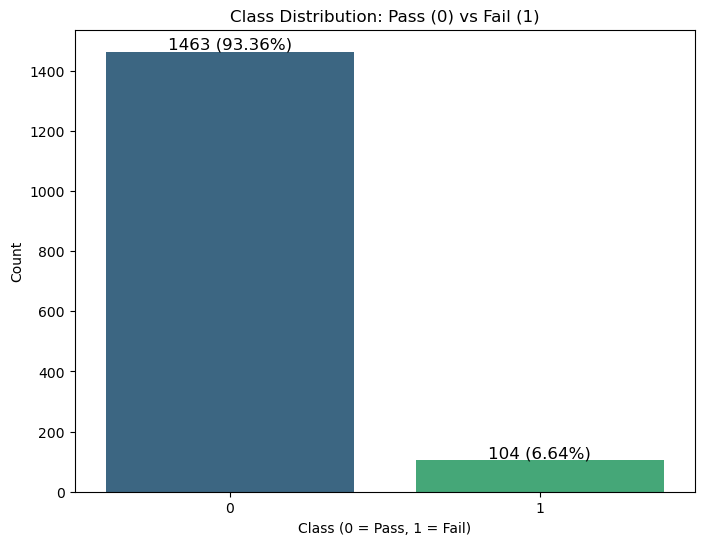


Class ratio (Fail:Pass): 0.07


In [21]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Pass/Fail', data=df, palette='viridis')
plt.title("Class Distribution: Pass (0) vs Fail (1)")
plt.xlabel("Class (0 = Pass, 1 = Fail)")
plt.ylabel("Count")

# Add percentage labels
total = len(df)
for i, v in enumerate(df['Pass/Fail'].value_counts()):
    pct = v / total * 100
    plt.text(i, v + 10, f"{v} ({pct:.2f}%)", ha='center', fontsize=12)

plt.show()

print("\nClass ratio (Fail:Pass):", round(df['Pass/Fail'].mean() / (1 - df['Pass/Fail'].mean()), 2))

**Key Insights**

The severe class imbalance (1:14) causes standard models to be heavily biased toward the majority class (Pass), resulting in **very low recall for the minority class (Fail)**.

Therefore, it is essential to:
- Prioritize **recall-oriented evaluation metrics** (e.g., Recall, Geometric Mean).
- Implement **cost-sensitive learning** to penalize failure misclassification more heavily.

### 3.7 Outlier Analysis

**Objective**  
Investigate the presence, distribution, and impact of outliers in sensor data to decide whether to remove, cap, or retain them.

**Why it matters**  
- Outliers in manufacturing sensor data can be **noise** (faulty sensors) or **rare failure signals** (extreme conditions leading to Fail).  
- Removing them risks losing critical information (especially with rare Fail class ~6.6%).  
- We use **IQR method** to detect, visualize distribution, and check class bias.

**Key Challenges**  
- Extremely high outlier prevalence (~99.92% rows affected).  
- Outliers spread across most features → not concentrated in few sensors.  
- Need to balance noise reduction vs. preserving rare defect signals.

**Analysis Steps**  
1. Identify rows with at least one outlier (train set).  
2. Distribution of outlier counts across features.  
3. Class distribution (Fail %) across outlier count bins.  
4. Fail % comparison: outlier rows vs. full train set.

In [22]:
# I. Identify rows with at least one outlier (train set)

outlier_thresholds = {}

# 1. Fit IQR-based outlier thresholds for each numeric column.
def fit_outlier_thresholds(df):
    for col in df.columns:
        if df[col].dtype.kind in 'bifc':
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outlier_thresholds[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# 2. Return set of row indices with at least one outlier
def get_outlier_indices(df):
    outlier_indices = set()
    for col in df.columns:
        if col in outlier_thresholds:
            lower, upper = outlier_thresholds[col]
            column_outliers = df[(df[col] < lower) | (df[col] > upper)].index
            outlier_indices.update(column_outliers)
    return list(outlier_indices)

# 3. Fit on train and get indices
fit_outlier_thresholds(X_train_1)

outlier_indices_train = get_outlier_indices(X_train_1)
outlier_indices_test = get_outlier_indices(X_test_1)

print(f"Train rows: {len(X_train_1)}")
print(f"Rows with at least 1 outlier: {len(outlier_indices_train)} ({len(outlier_indices_train)/len(X_train_1)*100:.2f}%)")
print(f"Test rows with at least 1 outlier: {len(outlier_indices_test)} ({len(outlier_indices_test)/len(X_test_1)*100:.2f}%)")

Train rows: 1253
Rows with at least 1 outlier: 1252 (99.92%)
Test rows with at least 1 outlier: 314 (100.00%)


**Key Insights**
- Nearly **100% of training rows (99.92%) contain at least one outlier**, indicating outliers are **widespread**, not isolated.  
- The Fail rate in outlier rows (~6.63%) is nearly identical to the overall dataset (~6.62%) → **no strong bias toward Fail**.  

**Implications**
- Outliers are a **natural characteristic of sensor data** (noisy tails) → avoid aggressive removal to prevent losing rare failure signals.  
- Prefer **outlier-robust approaches** such as tree-based models (e.g., XGBoost, Random Forest) or **RobustScaler** to mitigate impact without information loss.

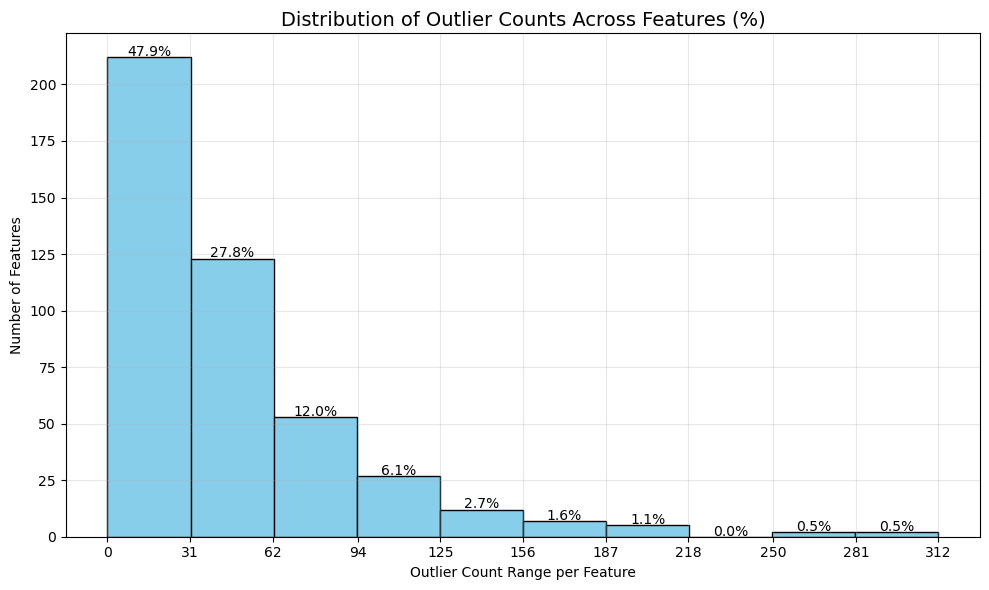

In [23]:
# II. Distribution of outlier counts across features

# Count outliers per feature and plot distribution with %
def plot_outlier_count_bins(df, bins=10):
    outlier_counts = []
    for col in df.columns:
        if df[col].dtype.kind in 'bifc':
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
            outlier_counts.append(count)

    counts_array = np.array(outlier_counts)
    total_cols = len(outlier_counts)
    max_count = counts_array.max()
    bin_edges = np.linspace(0, max_count, bins + 1)

    # Plot histogram
    plt.figure(figsize=(10, 6))
    counts, edges, patches = plt.hist(counts_array, bins=bin_edges, color='skyblue', edgecolor='black')
    
    for count, edge, patch in zip(counts, edges, patches):
        height = patch.get_height()
        percent = 100 * (count / total_cols)
        plt.text(edge + patch.get_width() / 2, height + 0.5, f'{percent:.1f}%', ha='center', fontsize=10)

    plt.xlabel("Outlier Count Range per Feature")
    plt.ylabel("Number of Features")
    plt.title("Distribution of Outlier Counts Across Features (%)", fontsize=14)
    plt.xticks(bin_edges.round(0))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_outlier_count_bins(X_train_1, bins=10)

**Key Insights**
- ~47.7% of features have **low outlier counts (0–31)** → nearly half of the sensors are relatively clean.  
- ~52.3% show **moderate to high outliers**, indicating noise is **widely distributed**, not concentrated.  
- The distribution has a **right-skewed tail**, with ~50–60 features being highly noisy.  

**Implications**
- Outliers are **systematic, not random** → avoid dropping features solely based on outlier counts.  
- Focus on **feature selection** to handle highly noisy features, rather than removing outlier rows.

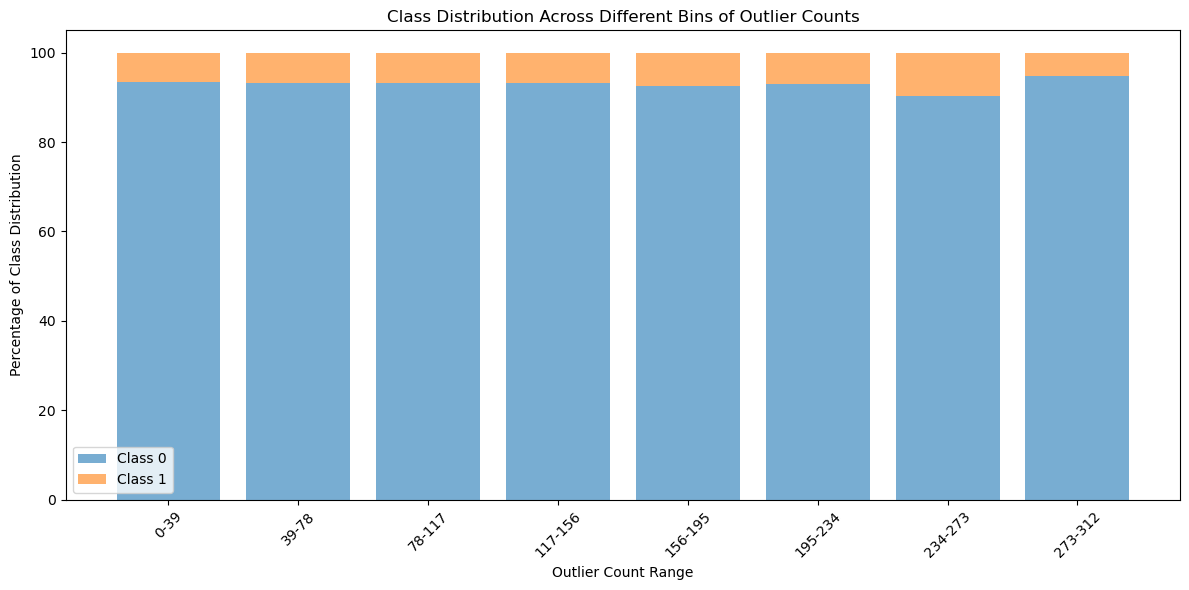

In [24]:
# III. Class Distribution Across Outlier Count Bins
y_trained = y_train.copy()

# Visualize how class distribution (Pass/Fail) varies across feature groups
def plot_class_distribution_in_outlier_bins(df, labels, bins=8, outlier_threshold=112):
    outlier_counts = {}

    # Count outliers per numeric feature using IQR method
    for col in df.columns:
        if df[col].dtype.kind in 'bifc':  # ktra numeric: b (boolean), i(integer), f(float), c(complex)
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            count_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0] 
            #Shape: (dòng, cột) => shape[0]: lấy số dòng => số lượng outlier
            if count_outliers > 0:
                outlier_counts[col] = count_outliers #Có outlier thì lưu dictionary


    # Convert to DataFrame and create bins based on outlier counts
    outlier_counts_df = pd.DataFrame(list(outlier_counts.items()), columns=['Column', 'Count'])
    max_count = outlier_counts_df['Count'].max()
    bin_edges = np.linspace(0, max(max_count, outlier_threshold), bins + 1)
    outlier_counts_df['Bin'] = pd.cut(outlier_counts_df['Count'], bin_edges, include_lowest=True, labels=range(bins))

    # For each bin, collect indices of rows that contain outliers
    bin_class_distributions = {bin_label: [] for bin_label in range(bins)}

    for bin_label in range(bins):
        columns_in_bin = outlier_counts_df[outlier_counts_df['Bin'] == bin_label]['Column']
        outlier_indices = set() # Set để ko trùng lặp index
        for col_name in columns_in_bin:
            Q1 = df[col_name].quantile(0.25)
            Q3 = df[col_name].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col_name] < lower_bound) | (df[col_name] > upper_bound)].index
            outlier_indices.update(outliers)

        # Compute class distribution (%) within outlier rows of each bin
        if outlier_indices:
            class_distribution = labels.loc[list(outlier_indices)].value_counts(normalize=True) * 100
            for class_label in class_distribution.index:
                bin_class_distributions[bin_label].append(class_distribution[class_label])
        else:
            bin_class_distributions[bin_label] = [0, 0]  # No outliers found for this bin


    # Plot stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    bin_labels = [f'{int(bin_edges[i])}-{int(bin_edges[i+1])}' for i in range(len(bin_edges)-1)]

    # Average class percentages per bin
    class_0_percentages = [dist[0] if dist else 0 for dist in bin_class_distributions.values()]
    class_1_percentages = [dist[1] if len(dist) > 1 else 0 for dist in bin_class_distributions.values()]

    ax.bar(bin_labels, class_0_percentages, label='Class 0', alpha=0.6)
    ax.bar(bin_labels, class_1_percentages, bottom=class_0_percentages, label='Class 1', alpha=0.6)

    ax.set_xlabel('Outlier Count Range')
    ax.set_ylabel('Percentage of Class Distribution')
    ax.set_title('Class Distribution Across Different Bins of Outlier Counts')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
    plt.show()

plot_class_distribution_in_outlier_bins(X_train_1, y_trained, bins=8)

**Key Insights**
- Fail rate across outlier bins remains **relatively stable** (≈2–5%), with no significant increase in higher bins.  
- Outliers show **no strong bias toward the Fail class**, with similar proportions across the dataset.  

**Implications**
- Outliers mainly reflect **sensor noise (extreme values)** rather than distinct failure signals → no need for aggressive treatment.  
- Prefer **robust models** (e.g., XGBoost, Random Forest) that naturally handle outliers and support **high recall without information loss**.

Total outlier rows: 1252
Fail % in outlier rows: 6.63%
Fail % in full train set: 6.62%


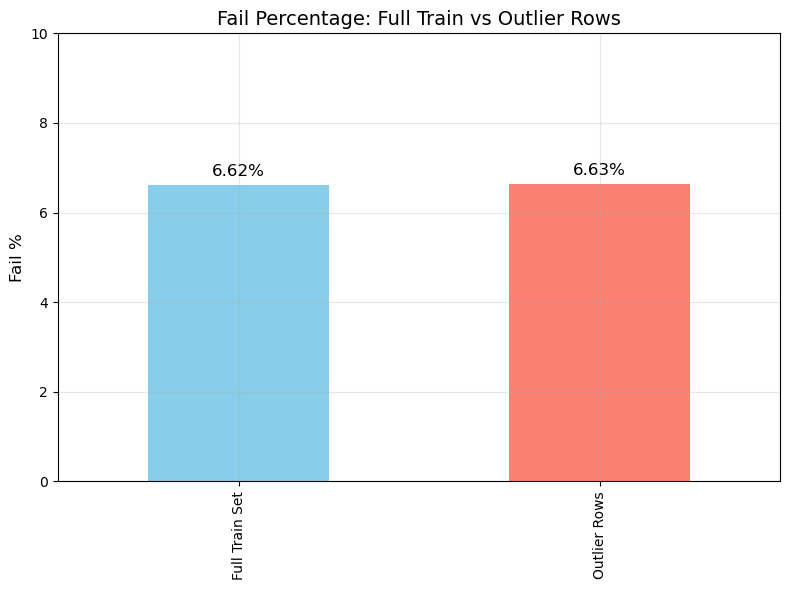

In [25]:
# IV. Fail % Comparison: Outlier Rows vs Full Train

def identify_outliers_with_target(X_df, y_series):
    """Return DataFrame of rows with at least one outlier + target."""
    outlier_indices = set()

    # Detect outlier rows across all numeric features
    for col in X_df.columns:
        if X_df[col].dtype.kind in 'bifc':
            Q1 = X_df[col].quantile(0.25)
            Q3 = X_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            column_outliers = X_df[(X_df[col] < lower) | (X_df[col] > upper)].index
            outlier_indices.update(column_outliers)
    
    # Create DataFrame of outlier rows + target
    outlier_df = X_df.loc[list(outlier_indices)].copy()
    outlier_df['Pass/Fail'] = y_series.loc[list(outlier_indices)]
    return outlier_df

outlier_rows = identify_outliers_with_target(X_train_1, y_trained)

print("Total outlier rows:", len(outlier_rows))
print(f"Fail % in outlier rows: {round(outlier_rows['Pass/Fail'].mean() * 100, 2)}%")
print(f"Fail % in full train set: {round(y_trained.mean() * 100, 2)}%")

# Bar plot comparison
fail_rates = pd.Series({
    'Full Train Set': y_train.mean() * 100,
    'Outlier Rows': outlier_rows['Pass/Fail'].mean() * 100
})

plt.figure(figsize=(8, 6))
fail_rates.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Fail Percentage: Full Train vs Outlier Rows", fontsize=14)
plt.ylabel("Fail %", fontsize=12)
plt.ylim(0, 10)
for i, v in enumerate(fail_rates):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key Insights**
- Fail rate in outlier rows (6.63%) is nearly identical to the overall training set (6.62%) → negligible difference (~0.01%).  
- Outliers are widespread but **do not carry distinct failure signals**.  

**Implications**
- Retaining outliers is **safe**, avoiding loss of rare but valuable defect signals.  
- **Business value:** Focus on robust preprocessing (e.g., RobustScaler) and **tree-based models** to handle noise, supporting **high recall and reduced defect-miss cost** in the Dual-Monitoring system.

#### **Conclusion: Outlier Analysis**

Outliers are **widespread and naturally noisy**, but show **no bias toward the Fail class**.  
→ Retain outliers and prioritize **robust scaling** and **tree-based models** to optimize **cost-sensitive prediction**.

### 3.8 Correlation Analysis

**Objective**  
Examine linear relationships among features and with the target (Fail) to:  
- Detect multicollinearity (risk of unstable models).  
- Identify strong predictors of Fail.  
- Guide dimensionality reduction and feature selection strategy.

**Key Challenges**  
- High-dimensional data (noise & redundancy possible).  
- Weak individual feature-target correlations expected (signal dispersed).

**Analysis Steps**  
1. Heatmap of correlations among top 50 high-variance features.  
2. Top 20 absolute correlations with target (Fail).

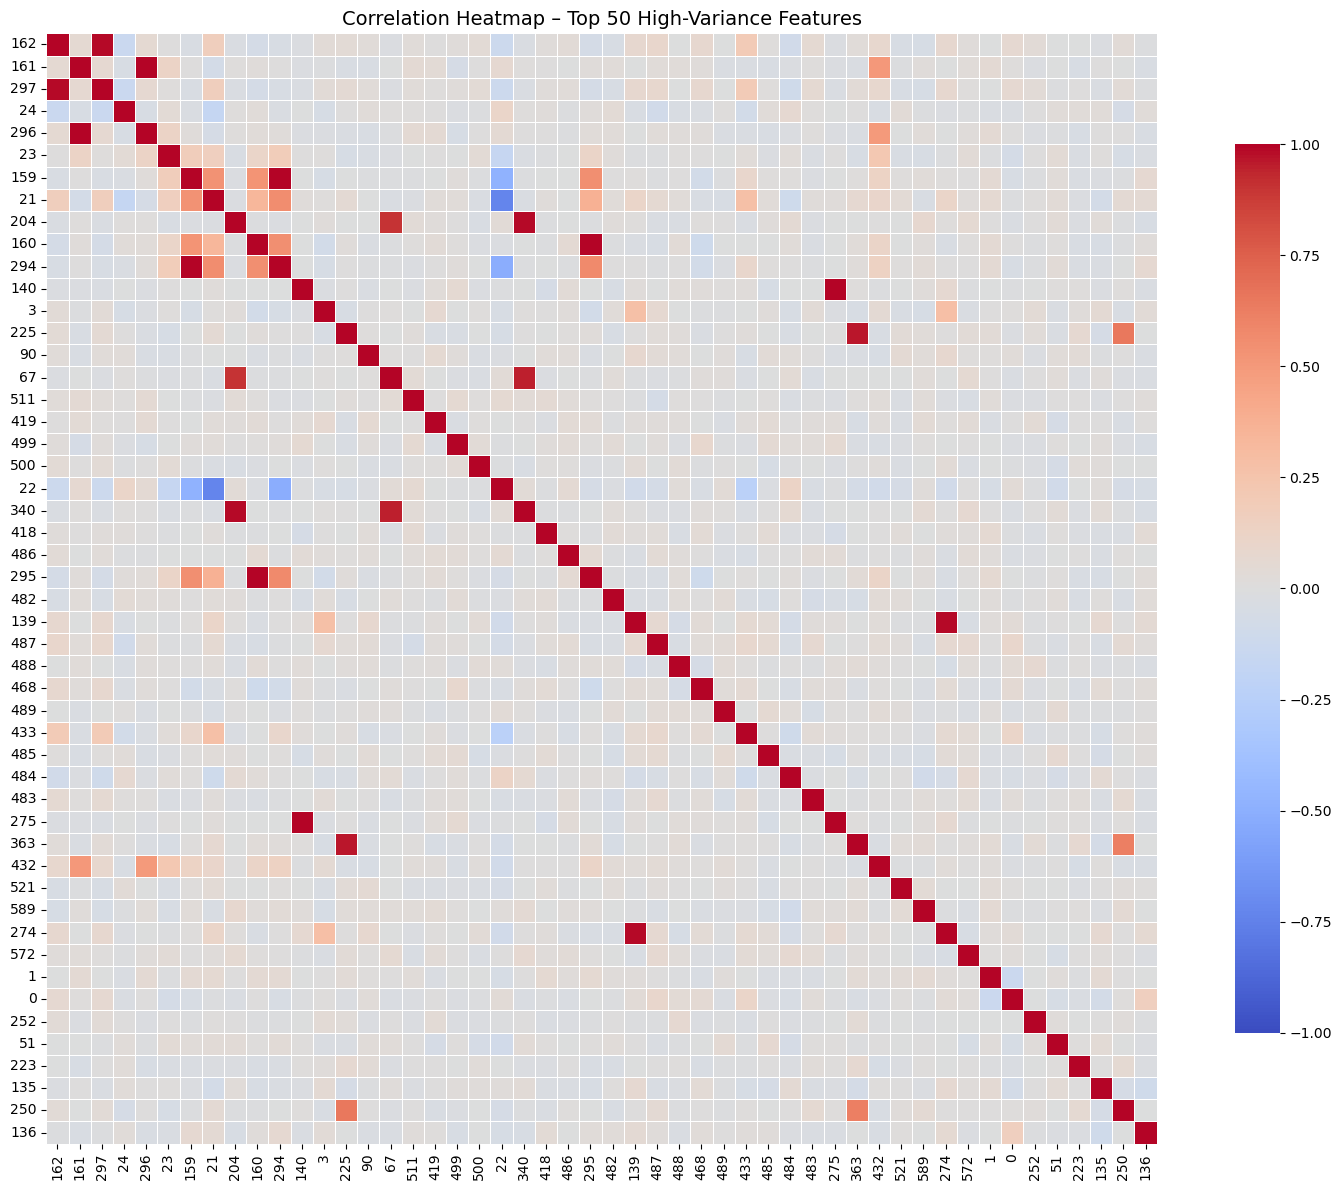

In [26]:
# I. Correlation Heatmap – Top 50 High-Variance Features

# Select top 50 features by variance
variances = X_train_1.var().sort_values(ascending=False)
top_var_cols = variances.head(50).index

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    X_train_1[top_var_cols].corr(),
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap – Top 50 High-Variance Features", fontsize=14)
plt.tight_layout()
plt.show()

**Key Insights**
- Overall correlations are **relatively low** (|corr| mostly ≤ 0.5–0.75), with very few pairs exceeding 0.8.  
- No clear evidence of **strong multicollinearity clusters** → features are relatively independent.  

**Implications**
- **VIF-based filtering is unnecessary**.  
- Predictive signals are **distributed across many features** → require:  
  - **Dimensionality reduction**, or  
  - **Hybrid feature selection approaches**.


Top 20 features correlated with Pass/Fail:
103    0.1726
510    0.1439
59     0.1258
348    0.1108
129    0.1076
431    0.1050
64     0.1041
21     0.0991
125    0.0947
430    0.0923
100    0.0918
434    0.0917
316    0.0900
435    0.0884
436    0.0865
28     0.0861
122    0.0850
351    0.0836
95     0.0829
213    0.0817
dtype: float64


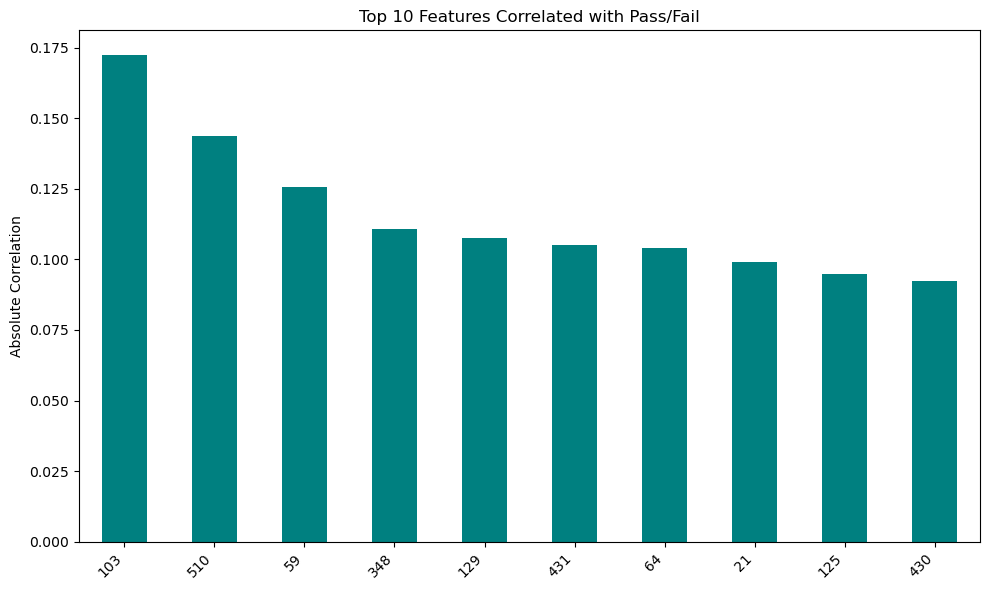

In [27]:
# 3.4.2 Top Correlation với Target (absolute)
corr_with_target = X_train_1.corrwith(y_trained).abs().sort_values(ascending=False).head(20)
print("\nTop 20 features correlated with Pass/Fail:")
print(corr_with_target.round(4))

# Bar plot top 10
plt.figure(figsize=(10, 6))
corr_with_target.head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Features Correlated with Pass/Fail")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key Insights**
- Feature–target correlations are **very weak** (|corr| max ≈ 0.173; معظم < 0.15).  
- No single feature dominates prediction → signals are **distributed across multiple features**.  

**Implications**
- Cannot rely on **individual features** for prediction.  
- Need to **aggregate information** across features via:  
  - **Dimensionality reduction** (e.g., PCA), or  
  - **Hybrid feature selection** (e.g., Boruta + RFECV).

## 4. Metrics Definition & Prioritization

### Real-World Context

In semiconductor manufacturing, the cost of **False Negatives (FN)** is significantly higher than **False Positives (FP)**.  
Missing a defective wafer can lead to **batch failure, high rework/scrap costs, and reputational damage**, while false alarms only incur minor inspection costs.  

→ Traditional metrics (Accuracy, F1) are **misleading** → prioritize **Recall** and **Total Cost of Quality (TCQ)**.

---

### Selected Metrics & Priorities

| Priority | Metric                | Purpose                                  |
|----------|----------------------|------------------------------------------|
| 1        | **Recall (Fail)**    | Minimize costly False Negatives          |
| 2        | **Geometric Mean**   | Balance Recall and Specificity           |
| 3        | **PR-AUC**           | Robust evaluation under class imbalance  |
| 4        | Precision            | Control False Positives                  |
| 5        | F1-Score             | Reference metric only                    |
| 6        | **TCQ (Cost)**       | Optimize real economic outcome           |

---

### Why Not Accuracy & ROC-AUC?

- **Accuracy** is biased toward the majority class (~93.4% Pass).  
- **ROC-AUC** is less informative under severe imbalance → PR-AUC is preferred.

---

### Metric Strategy

- **Model Training & Tuning**  
  - Primary: **Recall**  
  - Secondary: **Geometric Mean**

- **Threshold Optimization**  
  - Optimize based on **TCQ**

- **Final Evaluation**  
  - Report: **Recall, GM, PR-AUC, TCQ**

---

### Key Insights

- **FN drives the highest cost** → Recall is critical.  
- Severe imbalance → Accuracy/ROC-AUC are unreliable.  
- **TCQ reflects real business impact** → must guide decision-making.

---

### Implications

- Prioritize **high recall (early defect detection)**.  
- Use **cost-based threshold tuning** to balance FN vs FP.  
- Enable **business-driven decisions** aligned with real manufacturing costs.

---

→ Next step: **Feature Selection** to identify the most critical sensors.

## 5. Hybrid Feature Selection

**Objective**  
Reduce high-dimensional noisy data (590 features) while preserving strong failure signals and maximizing recall (cost-sensitive priority).

**Why Hybrid?**  
- Boruta: Identifies **all statistically relevant features** (robust to noise).  
- RFECV: Optimizes subset for **maximum predictive performance** (recall-focused).  
- Merge: Balances relevance + performance → reliable, interpretable input for both stages.

**3-Phase Strategy**

**Phase 1 – Boruta (All-Relevant Selection)**  
Goal: Find core features with strong statistical link to Fail (beyond random noise).  
Method: Compare real features vs shadow (permuted) features using Random Forest importance.

**Phase 2 – RFECV (Predictive Optimization)**  
Goal: Select optimal subset maximizing recall via recursive elimination + cross-validation.  
Method: Use RF estimator, recall scoring, stratified CV, enforce minimum Boruta core size.

**Phase 3 – Hybrid Merge**  
Goal: Combine results for balanced, reliable feature set.  
Method: Union of Boruta core + RFECV selected features → final input for modeling.

In [28]:
# Phase 1: Boruta – All-Relevant Feature Selection

X_train_2 = X_train_1.copy()
X_test_2 = X_test_1.copy()

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Initialize balanced RF estimator
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=SEED)

# Configure Boruta
boruta = BorutaPy(rf, n_estimators='auto', max_iter=100, verbose=0, random_state=SEED)

# Fit on train data
boruta.fit(X_train_2.values, y_train.values)

# Extract selected features
selected_features = X_train_2.columns[boruta.support_].tolist()
tentative_features = X_train_2.columns[boruta.support_weak_].tolist()
core_features = sorted(list(set(selected_features + tentative_features)))

print(f"Confirmed important features: {len(selected_features)}")
print(f"Tentative features: {len(tentative_features)}")

Confirmed important features: 5
Tentative features: 4


**Key Insights**
- Boruta converged after **100 iterations**, identifying **9 core features** (5 Confirmed + 4 Tentative).  
- These features consistently outperform shadow features → **strong statistical relevance to Fail**.  

**Implications**
- Boruta effectively removes **random noise** as an initial filtering step.  
- Its **all-relevant approach** may retain weak signals → requires **Phase 2 (RFECV)** for refinement based on predictive performance (Recall).  
- **Business value:** Early noise reduction helps focus on **truly relevant sensors** linked to product defects.

In [29]:
# Phase 2: RFECV – Recursive Feature Elimination with CV

from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

X_train_3 = X_train_2

# Initialize RF estimator
rf_rfecv = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1)

# Configure RFECV with recall focus
rfecv = RFECV(
    estimator=rf_rfecv,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='recall',  # Prioritize failure detection
    min_features_to_select=9,  # Enforce Boruta core minimum
    n_jobs=-1
)

rfecv.fit(X_train_3, y_train)

print(f"Optimal number of features selected (k): {rfecv.n_features_}")

Optimal number of features selected (k): 23


**Key Insights**
- RFECV selects **9 features**, optimized for **Recall** via cross-validation.  
- Recall-based scoring ensures retention of features **sensitive to Fail cases**.  

**Implications**
- RFECV complements Boruta by focusing on **real predictive performance**, not just statistical relevance.  
- Final features support **high recall in Stage 1**, reducing costly False Negatives.  
- **Business value:** Fewer features → **optimized resources** while maintaining strong defect detection capability.

In [30]:
# Phase 3: Hybrid Merge – Final Feature Set

# Get RFECV selected features
optimized_features = X_train_3.columns[rfecv.support_].tolist()

# Merge: ensure Boruta core is preserved
final_feature_set = sorted(list(set(core_features + optimized_features)))

print(f"Total final hybrid features: {len(final_feature_set)}")

# Update final datasets
X_train_final = X_train_3[final_feature_set]
X_test_final = X_test_2[final_feature_set]

# Display final feature sources
table_data = []
for i, feature in enumerate(final_feature_set, 1):
    source = []
    if feature in core_features: source.append("Boruta")
    if feature in optimized_features: source.append("RFECV")
    table_data.append({"STT": i, "Sensor ID": feature, "Source": " + ".join(source)})

df_features = pd.DataFrame(table_data)
display(df_features)

Total final hybrid features: 23


,STT,Sensor ID,Source
0,1,103,Boruta + RFECV
1,2,130,Boruta + RFECV
2,3,137,RFECV
3,4,146,RFECV
4,5,200,RFECV
5,6,205,RFECV
6,7,21,RFECV
7,8,213,Boruta + RFECV
8,9,281,RFECV
9,10,31,Boruta + RFECV


**Key Insights**
- Final selection yields **23 features**.

**Implications**
- The hybrid approach balances **statistical relevance (Boruta)** and **predictive power (RFECV)**.  
- Feature set is **ready for Stage 1** and **Stage 2**.  
- **Business value:** Reduced computation, faster deployment, and improved real-world defect detection.

## 6. Stage 1: Early Warning Station

**Objective**  
Build a **cost-sensitive XGBoost** model to provide early failure alerts with high recall and minimized economic cost.

**Why this stage?**  
- Failures are rare (~6.6%) but extremely costly (FN cost >> FP cost).  
- Need **high recall** to catch defects early → cost-sensitive learning.  
- Bayesian Optimization + TCQ-based threshold → balances detection power and economic impact.

**Expected Outcomes**  
- Recall ≥ 80–95%  
- Lowest possible Total Cost of Quality (TCQ)  
- Optimal threshold usually low (<0.5) to prioritize recall

**Process**  
1. Cost-sensitive XGBoost with scale_pos_weight tuning.  
2. Bayesian Optimization (Optuna) for hyperparameters.  
3. Fixed threshold in CV for fair evaluation.  
4. Final threshold search on validation (wide range) to minimize TCQ.  
5. Full evaluation on test set + comparison with baselines.

In [31]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix

# 1. Configuration & SEED
# Define misclassification costs
C_FN = 100
C_FP = 1
SEED = 42
FIXED_CV_THRESHOLD = 0.25 # Fixed threshold to ensure fair comparison during CV

def total_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fn * C_FN + fp * C_FP

# Stratified split for validation
X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(
    X_train_final, y_train, test_size=0.2, 
    stratify=y_train, random_state=SEED
)

# 2. Optuna Objective – Fixed Threshold in CV
def objective(trial):
    """
    Optimize XGBoost hyperparameters using cost-sensitive objective.
    A fixed threshold is used to avoid bias during CV.
    """
    params = {
        'n_estimators': 1500, # Tăng lên để Early Stopping có không gian chạy
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 5, 15, 30, 50, 80, 100]),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 15),
        'random_state': SEED,
        'n_jobs': -1,
        'tree_method': 'hist',
        'verbosity': 0
    }
    
    skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)
    fold_costs = []
    
    for train_idx, val_idx in skf.split(X_tr_sub, y_tr_sub):
        Xt, Xv = X_tr_sub.iloc[train_idx], X_tr_sub.iloc[val_idx]
        yt, yv = y_tr_sub.iloc[train_idx], y_tr_sub.iloc[val_idx]
        
        dtrain = xgb.DMatrix(Xt, label=yt)
        dval = xgb.DMatrix(Xv, label=yv)
        
        model = xgb.train(
            params, dtrain, 
            num_boost_round=1500,
            evals=[(dval, 'val')],
            early_stopping_rounds=100, # Cho model thêm thời gian hội tụ
            verbose_eval=False
        )
        # Convert probabilities to class predictions using fixed threshold
        proba = model.predict(dval)
        pred = (proba >= FIXED_CV_THRESHOLD).astype(int)
        fold_costs.append(total_cost(yv, pred))
    
    return np.mean(fold_costs)

# Run Optuna optimization
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=100, timeout=7200)

# 3. Train Final Model & Find Optimal Threshold (wide search)
best_params = study.best_params.copy()
best_params['n_estimators'] = 1500 # Sync với hàm objective

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_tr_sub, y_tr_sub)

# Search optimal threshold on validation set
val_proba = final_model.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.01, 0.9, 500) 
val_costs = [total_cost(y_val, (val_proba >= t).astype(int)) for t in thresholds]

opt_threshold = thresholds[np.argmin(val_costs)]

# 4. Final Evaluation on Test Set
test_proba = final_model.predict_proba(X_test_final)[:, 1]
test_pred = (test_proba >= opt_threshold).astype(int)

# In kết quả
from sklearn.metrics import recall_score, precision_score
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f"Best CV Cost: {study.best_value:.2f}")
print(f"Optimal Threshold (Validation): {opt_threshold:.4f}")
print(f"Test Cost: {total_cost(y_test, test_pred):,}")
print(f"Recall: {recall_score(y_test, test_pred):.2%}")

Best CV Cost: 179.50
Optimal Threshold (Validation): 0.0225
Test Cost: 449
Recall: 90.48%


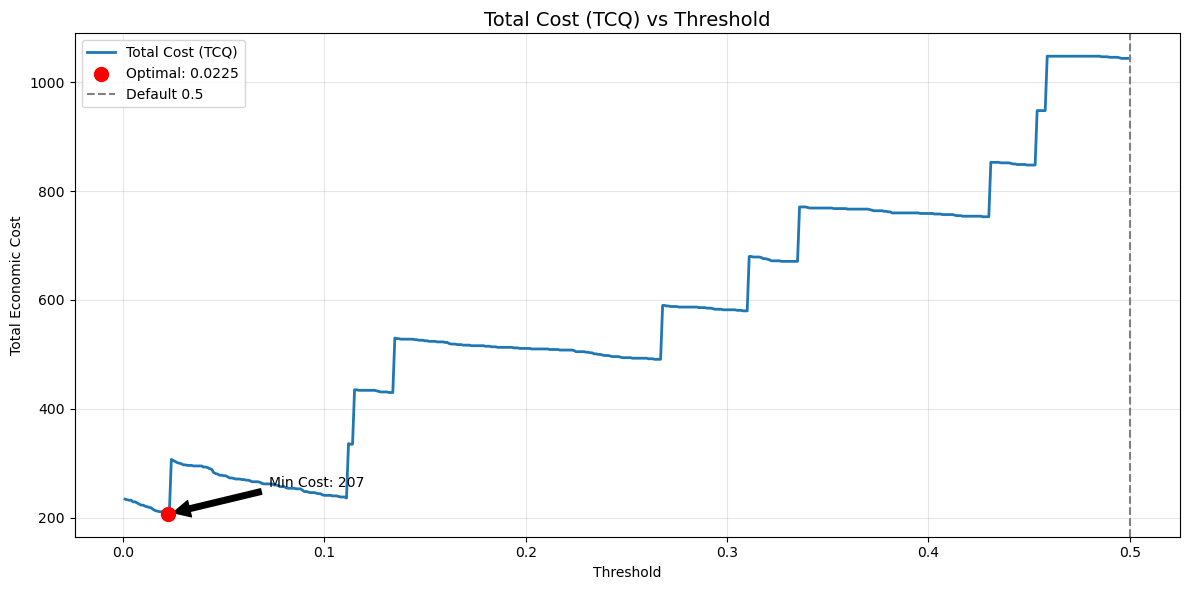

In [32]:
# 4. TCQ vs Threshold Curve
thresholds = np.linspace(0.001, 0.5, 500)
val_costs = [total_cost(y_val, (val_proba >= t).astype(int)) for t in thresholds]

plt.figure(figsize=(12, 6))
plt.plot(thresholds, val_costs, color='#1f77b4', linewidth=2, label='Total Cost (TCQ)')
plt.scatter(opt_threshold, min(val_costs), color='red', s=100, zorder=5,
            label=f'Optimal: {opt_threshold:.4f}')
plt.annotate(f'Min Cost: {int(min(val_costs)):,}', 
             xy=(opt_threshold, min(val_costs)), 
             xytext=(opt_threshold + 0.05, min(val_costs) + 50),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("Total Cost (TCQ) vs Threshold", fontsize=14)
plt.xlabel("Threshold")
plt.ylabel("Total Economic Cost")
plt.axvline(0.5, color='gray', linestyle='--', label='Default 0.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

══════════════════════════════════════════════════════════════════════
              FINAL RESULTS – STAGE 1 (EARLY WARNING)
══════════════════════════════════════════════════════════════════════
Optimal Threshold:          0.0225
Recall (Fail):              0.9048 (90.48%)
Geometric Mean:             0.3686
Precision:                  0.0709 (7.09%)
FN (Missed defects):        2 (Cost: 200)
FP (False alarms):          249 (Cost: 249)
Total Cost (TCQ):           449
══════════════════════════════════════════════════════════════════════


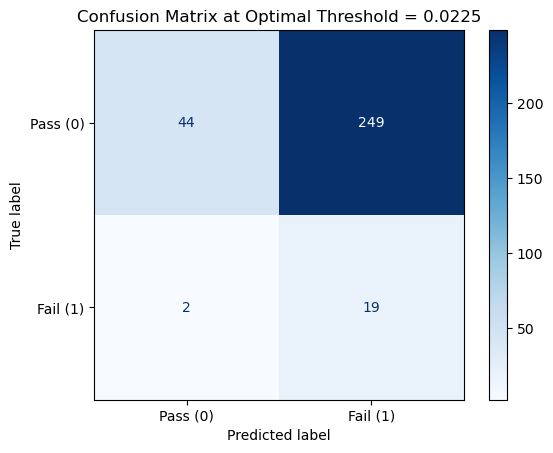

In [33]:
# 5. Final Evaluation & Report
test_proba = final_model.predict_proba(X_test_final)[:, 1]
test_pred = (test_proba >= opt_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred, labels=[0, 1]).ravel()
final_recall = recall_score(y_test, test_pred)
final_precision = precision_score(y_test, test_pred, zero_division=0)
final_gm = geometric_mean_score(y_test, test_pred)
total_cost_test = C_FN * fn + C_FP * fp

print("═" * 70)
print("              FINAL RESULTS – STAGE 1 (EARLY WARNING)")
print("═" * 70)
print(f"Optimal Threshold:          {opt_threshold:.4f}")
print(f"Recall (Fail):              {final_recall:.4f} ({final_recall*100:.2f}%)")
print(f"Geometric Mean:             {final_gm:.4f}")
print(f"Precision:                  {final_precision:.4f} ({final_precision*100:.2f}%)")
print(f"FN (Missed defects):        {fn} (Cost: {fn * C_FN:,})")
print(f"FP (False alarms):          {fp} (Cost: {fp * C_FP:,})")
print(f"Total Cost (TCQ):           {total_cost_test:,}")
print("═" * 70)

# Confusion Matrix visualization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, test_pred),
                              display_labels=['Pass (0)', 'Fail (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix at Optimal Threshold = {opt_threshold:.4f}")
plt.grid(False)
plt.show()

In [34]:
# 6. Model Comparison Table
# Total Cost
C_FN = 100 
C_FP = 1

def calculate_tcq(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fn * C_FN) + (fp * C_FP)

# 2. Define model comparison
models = {
    "XGBoost Default": xgb.XGBClassifier(random_state=SEED, n_jobs=1),
    "Cost-Sensitive XGBoost": xgb.XGBClassifier(scale_pos_weight=14, random_state=SEED, n_jobs=1),
    "Proposed (Bayesian+CS)": xgb.XGBClassifier(**best_params)
}

comparison_results = []

for name, model in models.items():
    model.fit(X_tr_sub, y_tr_sub)
    y_probs = model.predict_proba(X_test_final)[:, 1]
    
    threshold = opt_threshold if name == "Proposed (Bayesian+CS)" else 0.5
    y_pred = (y_probs >= threshold).astype(int)
    
    comparison_results.append({
        "Model": name,
        "Recall (Fail)": recall_score(y_test, y_pred),
        "G-Mean": geometric_mean_score(y_test, y_pred),
        "PR-AUC": average_precision_score(y_test, y_probs),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "TCQ (Cost)": calculate_tcq(y_test, y_pred)
    })

df_final = pd.DataFrame(comparison_results).sort_values("TCQ (Cost)")

print("═" * 105)
print(f"{'COMPARISON TABLE OF MONITORING SYSTEM PRODUCT PERFORMANCE':^105}")
print("═" * 105)
print(df_final.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))
print("═" * 105)

═════════════════════════════════════════════════════════════════════════════════════════════════════════
                        COMPARISON TABLE OF MONITORING SYSTEM PRODUCT PERFORMANCE                        
═════════════════════════════════════════════════════════════════════════════════════════════════════════
                 Model  Recall (Fail)  G-Mean  PR-AUC  Precision  F1-Score  TCQ (Cost)
Proposed (Bayesian+CS)         0.9048  0.3686  0.1791     0.0709    0.1315         449
       XGBoost Default         0.0952  0.3086  0.2244     1.0000    0.1739        1900
Cost-Sensitive XGBoost         0.0476  0.2178  0.1809     0.5000    0.0870        2001
═════════════════════════════════════════════════════════════════════════════════════════════════════════


In [35]:
# 7. Alarm Output for Stage 2
df_test_results = X_test_final.copy()
df_test_results['True_Label'] = y_test.values
df_test_results['Predicted_Prob'] = test_proba
df_test_results['Predicted_Label'] = test_pred

df_alarms = df_test_results[df_test_results['Predicted_Label'] == 1].copy()

print(f"Total alarms sent to Stage 2: {len(df_alarms)}")
print(f"- True Positives (real defects): {len(df_alarms[df_alarms['True_Label'] == 1])}")
print(f"- False Positives: {len(df_alarms[df_alarms['True_Label'] == 0])}")

Total alarms sent to Stage 2: 268
- True Positives (real defects): 19
- False Positives: 249


## 7. Stage 2: Diagnosis Station

**Objective**  
Transform continuous sensor data into interpretable discrete states for Bayesian Network (Stage 2).  
Build explainable BN to learn causal structure, estimate probabilities, and perform root-cause inference.

**Why this step?**  
- Continuous data → too many unique values → CPTs explode in size.  
- Discretisation (k-means + Elbow) → reduces complexity while preserving signal.  
- BN → captures dependencies, provides XAI (root-cause probabilities) → critical for diagnosis after alert.

**Process**  
1. Discretisation: k-means clustering per feature (Elbow-optimized k).  
2. Structure Learning: Hill-Climb + BIC score.  
3. Parameter Learning: MLE for CPTs.  
4. Inference & RCA: Variable Elimination for P(Fail | evidence) and sensor importance.

### 7.1. Discretisation for Bayesian Network

**Objective**

Convert continuous sensor data into **discrete states** to:  
- Enable efficient **Bayesian Network (BN)** modeling (avoid large CPTs)  
- Preserve **rare failure signals**  
- Improve **interpretability** for Stage 2 (Root-Cause Analysis)

**Why Discretisation?**
- SECOM data is **highly continuous** → BN would require massive CPTs.  
- Continuous BN assumes **Gaussian distribution**, unsuitable for **skewed, noisy, heavy-tailed data**.  
- Discrete states (e.g., Low/Normal/High) align with **engineering intuition** and support actionable insights.

**Method Selection: k-means + Elbow**
- Avoid **Equal Width/Frequency** → may lose important extreme values.  
- Avoid **Entropy-based methods** → risk of data leakage.  
- **k-means + Elbow**:  
  - Adapts to **skewed distributions**  
  - Automatically determines optimal **k (2–5)**  
  - Preserves **distribution structure** (including tails)  
  - No target usage → **leakage-free**

**Workflow**
1. Check unique values:  
   - If low (<10) → simple binning  
   - If high → apply **k-means + Elbow**  
2. Assign interpretable labels (**Low / Normal / High**)  
3. Transform all features → generate **discrete dataset for BN**

**Business Value**
- Enables **interpretable CPTs** → engineers can act on insights (e.g., “Sensor X = High → check module”).  
- Preserves rare failure signals → improves **diagnosis accuracy** in Stage 2.  
- Reduces **diagnosis time and operational cost** in production.

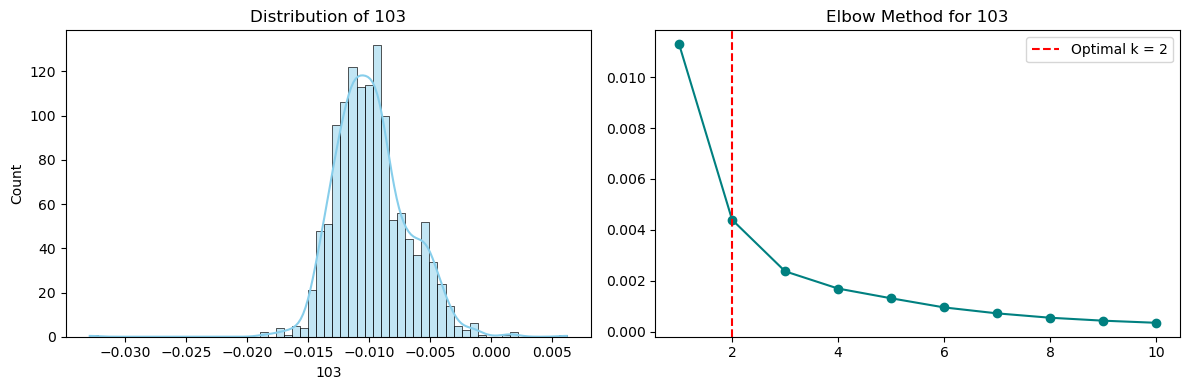

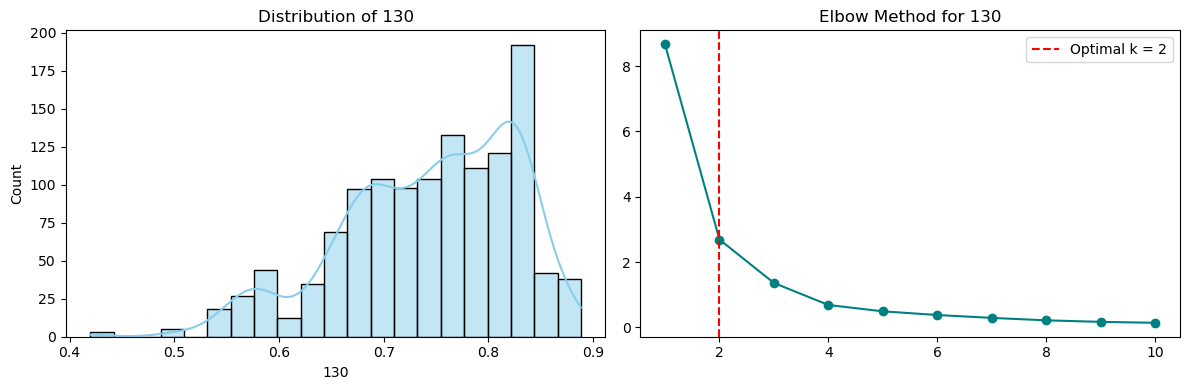

,103,130,137,146,200,205,21,213,281,31,...,39,423,469,477,510,59,64,75,81,91
1198,Low,High,High,Low,Low,Low,Normal,Low,Low,Low,...,Low,Low,Low,Low,Low,Low,Low,High,High,Low
436,High,High,Low,Low,Low,Low,Normal,Normal,Low,Low,...,Low,High,Low,Low,Low,Low,High,High,High,Low
635,Low,High,High,High,Low,Low,Normal,Low,High,Low,...,Low,Low,Low,Low,Low,Low,Low,High,High,Low
996,Low,Low,Low,Low,Low,Low,Normal,Normal,Low,Low,...,Low,High,Low,Low,Low,Low,High,High,Low,Low
782,High,High,Low,Low,Low,Low,Normal,Normal,Low,Low,...,Low,Low,Low,Low,Low,Low,Low,Low,High,Low
1109,Low,High,Low,Low,Low,Low,Normal,Normal,Low,Low,...,Low,Low,Low,Low,Low,Low,High,Low,High,High
437,Low,High,Low,High,Low,Low,Normal,Low,Low,Low,...,Low,Low,Low,Low,Low,Low,Low,Low,High,Low
86,High,High,Low,Low,Low,Low,Normal,Normal,Low,Low,...,Low,High,Low,Low,Low,Low,High,Low,Low,High
1148,Low,High,Low,Low,Low,Low,Normal,Low,Low,Low,...,Low,High,Low,Low,Low,Low,Low,High,High,Low
1387,Low,High,Low,Low,Low,Low,Low,Normal,Low,Low,...,Low,Low,Low,Low,Low,Low,High,Low,High,High


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from IPython.display import display

def discretization(df_in, col_name, max_k=10, unique_threshold=10, show_plots=True):
    """
    Discretize a continuous feature using K-Means clustering.
    The optimal number of bins is determined via the Elbow method.
    """
    col_series = df_in[col_name]
    col_data_clean = col_series.dropna().values.reshape(-1, 1)
    unique_count = col_series.nunique()
    
    # 1. Handle features with low cardinality
    if unique_count <= unique_threshold:
        return pd.cut(col_series, bins=unique_count, labels=[f"L{i}" for i in range(unique_count)])

    # 2. Plot distribution & compute Elbow
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        # Distribution plot
        sns.histplot(col_series, kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f"Distribution of {col_name}")
        
        # Compute WSS (Within-Cluster Sum of Squares)
        wss = []
        K_range = range(1, max_k + 1)
        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(col_data_clean)
            wss.append(kmeans.inertia_)

        # Use second derivative to find elbow point
        deltas = np.diff(wss)
        acceleration = np.diff(deltas)
        optimal_k = np.argmax(acceleration) + 2 if len(acceleration) > 0 else 3

        # Limit number of bins to avoid over-fragmentation
        optimal_k = max(2, min(optimal_k, 5)) 
        axes[1].plot(K_range, wss, marker='o', color='teal')
        axes[1].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
        axes[1].set_title(f"Elbow Method for {col_name}")
        axes[1].legend()
        plt.tight_layout()
        plt.show()
    else:
        # Faster mode without plotting
        wss = [KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(col_data_clean).inertia_ for k in range(1, max_k + 1)]
        optimal_k = np.argmax(np.diff(np.diff(wss))) + 2 if len(np.diff(np.diff(wss))) > 0 else 3
        optimal_k = max(2, min(optimal_k, 5))

    # 3. Final clustering
    km_final = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=10).fit(col_data_clean)
    
    # Sort clusters based on centroid values (ensure ordinal meaning)
    centroids = km_final.cluster_centers_.flatten()
    rank_map = {old_label: rank for rank, old_label in enumerate(np.argsort(centroids))}
    
    # Assign cluster labels to all data (including NaNs → filled with median)
    raw_labels = km_final.predict(col_series.fillna(col_series.median()).values.reshape(-1, 1))
    sorted_labels = pd.Series(raw_labels, index=col_series.index).map(rank_map)
    
    # Map numeric clusters to interpretable categories
    mapping = {0: 'Low', 1: 'High'} if optimal_k == 2 else ({0: 'Low', 1: 'Normal', 2: 'High'} if optimal_k == 3 else {i: f'L{i+1}' for i in range(optimal_k)})
    return sorted_labels.map(mapping)

# Apply discretization to all features
X_train_discrete = pd.DataFrame(index=X_train_final.index)

# Show plots only for first 2 features for inspection
for i, col in enumerate(X_train_final.columns):
    temp_plot = True if i < 2 else False
    X_train_discrete[col] = discretization(X_train_final, col, show_plots=temp_plot)

# Results
display(X_train_discrete.head(10))

**Key Insights**
- K-means + Elbow selects **k = 2 for most features**, indicating clear **bimodal distributions** (Low vs High).  
- Data is **skewed/noisy** → k-means preserves tail structure better than equal binning methods.  
- Resulting dataset (**X_train_discrete**) provides **interpretable states** (Low/Normal/High), suitable for BN and engineers.  

**Implications**
- Discretisation significantly reduces **CPT complexity** (from thousands of values to 2–3 states).  
- Preserves **rare failure signals** in extreme regions.  
- **Business value:** Enables BN to learn clear dependencies (e.g., *High → Fail*), supporting **actionable root-cause analysis** in Stage 2.

### 7.2 Causal Structure Learning

**Objective**
Learn a **Directed Acyclic Graph (DAG)** from discrete data to:  
- Capture **causal dependencies** between sensors and Fail  
- Reduce CPT search space → improve efficiency & interpretability  
- Enable **root-cause analysis (RCA)** in Stage 2  

**Approach**
Two approaches exist:  
- **Expert-driven** → not suitable (SECOM sensors are anonymous)  
- **Data-driven** → selected for this project  

→ Use **Score-based learning: Hill-Climb Search + BIC**

**Why Hill-Climb + BIC?**
- **BIC penalizes complexity** → avoids overfitting, produces simpler graphs  
- Efficient with reduced feature set (**13 features**)  
- Handles **noisy data** well  
- Faster than constraint-based methods (no independence tests)  
- Fully **data-driven** → no domain bias  

**Role of Discretisation**
- Discrete states (**Low/Normal/High**) reduce **CPT size**  
- Improve **learning stability and speed**  
- Ensure compatibility with BN assumptions  

**Workflow**
1. Prepare **discrete dataset + target (Fail)**  
2. Apply **Hill-Climb + BIC** for structure learning  
3. Visualize **DAG**  
4. Proceed to **parameter learning (MLE)** and inference  

**Key Insight**
- A compact, data-driven DAG enables **interpretable causal relationships** (e.g., *Sensor A → Sensor B → Fail*).  

**Implication**
- Supports **actionable root-cause analysis**, allowing engineers to trace failure pathways and respond effectively.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'103': 'C', '130': 'C', '137': 'C', '146': 'C', '200': 'C', '205': 'C', '21': 'C', '213': 'C', '281': 'C', '31': 'C', '316': 'C', '319': 'C', '33': 'C', '39': 'C', '423': 'C', '469': 'C', '477': 'C', '510': 'C', '59': 'C', '64': 'C', '75': 'C', '81': 'C', '91': 'C', 'Fail': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'103': 'C', '130': 'C', '137': 'C', '146': 'C', '200': 'C', '205': 'C', '21': 'C', '213': 'C', '281': 'C', '31': 'C', '316': 'C', '319': 'C', '33': 'C', '39': 'C', '423': 'C', '469': 'C', '477': 'C', '510': 'C', '59': 'C', '64': 'C', '75': 'C', '81': 'C', '91': 'C', 'Fail': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'103': 'C', '130': 'C', '137': 'C', '146': 'C', '200': 'C', '205': 'C', '21': 'C', '213': 'C', '281': 'C', '31': 'C', '316

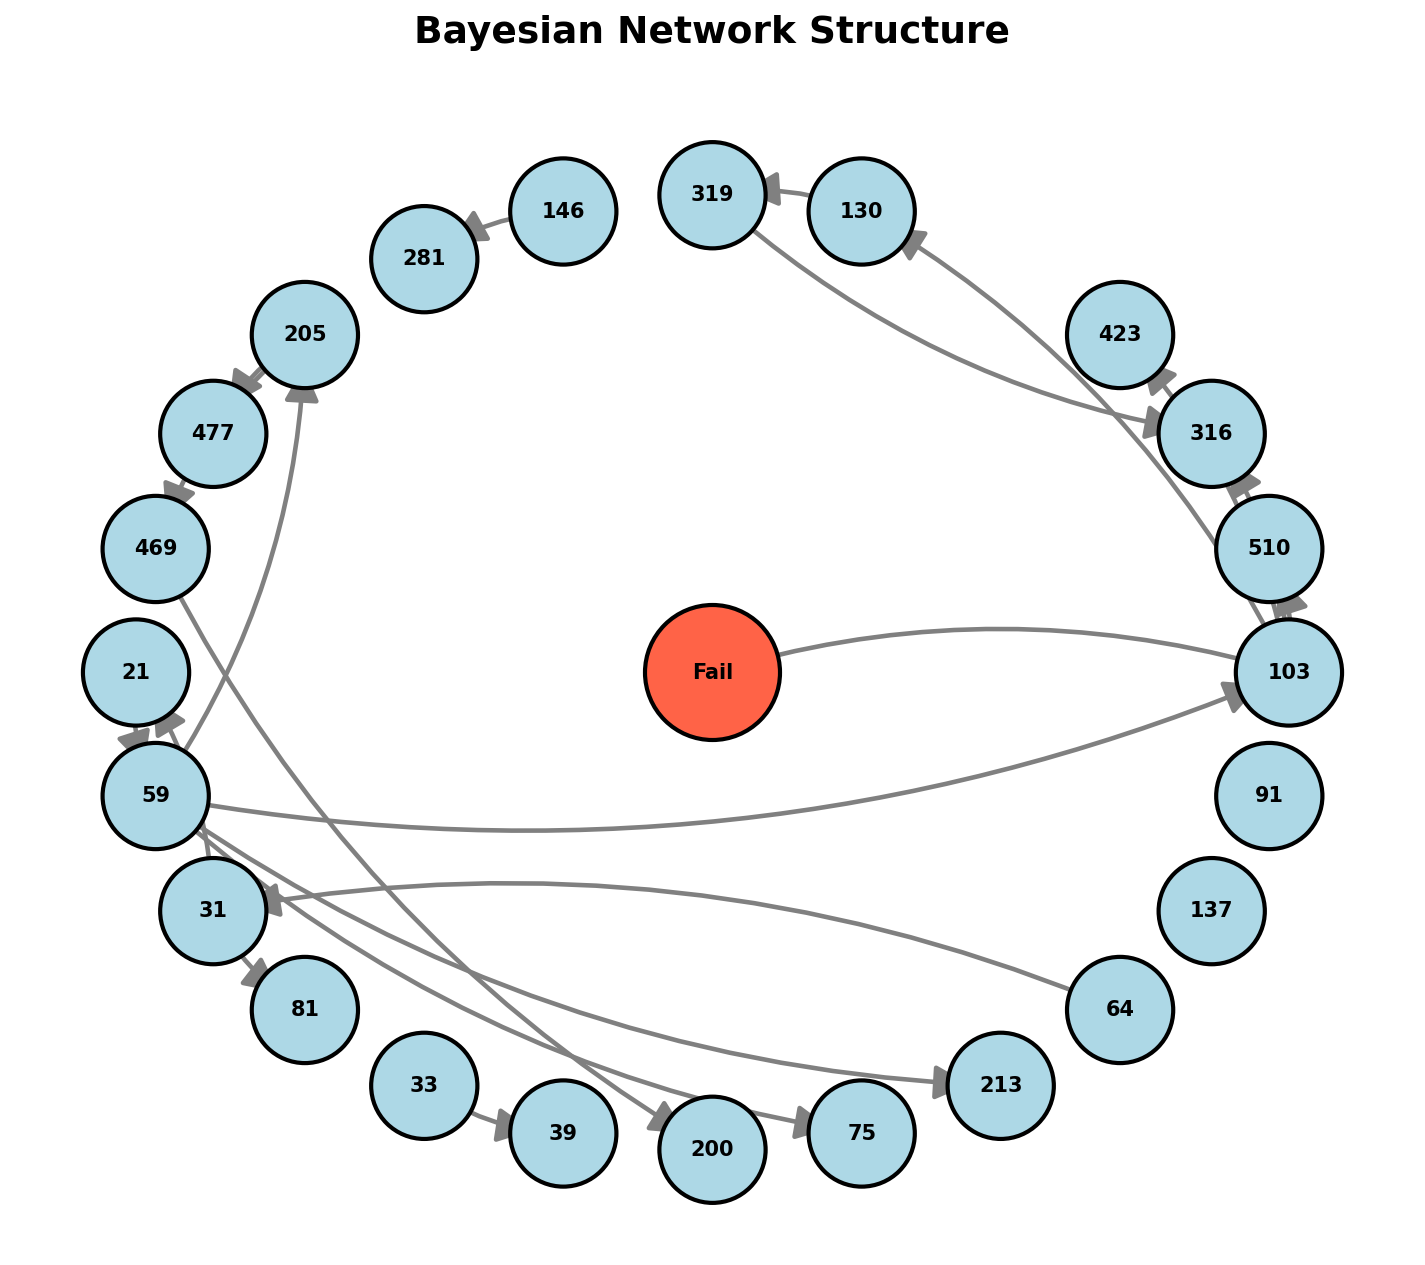

In [37]:
import matplotlib.pyplot as plt
import networkx as nx
from pgmpy.estimators import HillClimbSearch, BIC

# Prepare data for BN
df_train_bn = X_train_discrete.copy()
df_train_bn['Fail'] = y_train.map({0: 'Pass', 1: 'Fail'}).values
df_train_bn.columns = df_train_bn.columns.astype(str)

# Structure learning with Hill-Climb + BIC
hc = HillClimbSearch(df_train_bn)
best_model = hc.estimate(scoring_method=BIC(df_train_bn))

# Create graph
G = nx.DiGraph(best_model.edges())
G.add_nodes_from(df_train_bn.columns)

# Layout & visualization
pos = nx.circular_layout(G)
if 'Fail' in pos:
    pos['Fail'] = (0, 0)

node_colors = ['#ff6347' if node == 'Fail' else '#add8e6' for node in G.nodes()]
node_sizes = [4200 if node == 'Fail' else 2600 for node in G.nodes()]

plt.figure(figsize=(12, 10), dpi=150)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=2.2, arrows=True, arrowsize=35, arrowstyle='-|>',
                       connectionstyle="arc3,rad=0.15", min_source_margin=15, min_target_margin=15)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=2)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
plt.title("Bayesian Network Structure", fontsize=18, fontweight='bold', pad=25)
plt.axis('off')
plt.show()

**Key Insights**
- **Hill-Climbing + BIC** produced a **compact DAG** with **Fail at the center**, receiving multiple direct edges from critical sensors.  
- The DAG clearly represents **conditional dependencies** among SECOM sensors, supporting explanation and root-cause diagnosis.

**Critical Control Points**
- **Fail node** has multiple direct parents (e.g., 103, 21, 59, 281, 146, 31, 81, 91, 64, 510).  
- **Sensor 103** shows the strongest influence → **key control point**.  
- Monitoring and controlling these sensors can **significantly reduce failure probability**.

**Information Interaction Clusters**
- Sensors form **tightly connected clusters** (e.g., 103–510–316–423, 59–205–477–469–200).  
- These clusters reflect **physical/logical interactions** in the production process.  
- Failures often result from **combined sensor effects**, not a single sensor.

**Feature Pruning & Noise Reduction**
- Peripheral nodes (e.g., 137, 91, 33, 39) have **few connections** → minimal impact on Fail.  
- BN naturally **filters noise and simplifies feature set**, supporting earlier feature selection.

**Conclusion & Business Value**
- Bayesian Network is not just predictive but also a **powerful RCA tool**.  
- Highlights **sensors/clusters with highest impact** → supports **condition-based maintenance**.  
- Maintenance resources can be focused on **critical sensors** (103, 59, 21…), reducing **downtime and corrective costs**.

### 7.3 Parameter Learning & Inference

**Objective**
- Learn **Conditional Probability Tables (CPTs)** from discrete data  
- Perform **inference** to:  
  - Compute **P(Fail)** (baseline failure probability)  
  - Query **P(Fail | evidence)** → identify root causes when Stage 1 alerts  
  - Evaluate sensor importance via **Mutual Information**

**Why This Step?**
- DAG only shows **dependencies**, not exact probabilities  
- CPTs quantify risk (e.g., **P(Fail | Sensor 103 = High) = 0.66**)  
- Inference transforms BN into a **practical RCA tool**  
- **Business value:** Engineers can prioritize checks on sensors with highest conditional risk → reduce **downtime** and **corrective costs**

**Workflow**
1. **Parameter Learning**: Maximum Likelihood Estimator (MLE) to learn CPTs  
2. Validate model consistency  
3. Visualize key CPTs (e.g., **P(Fail | Sensor 103)**)  
4. Compute **Mutual Information** to rank sensor influence on Fail  
5. Perform **Inference**:  
   - Query **P(Fail | evidence)**  
   - RCA: **P(sensor | Fail)**

**Key Insights**
- CPTs reveal **conditional failure probabilities** across critical sensors  
- Mutual Information ranking highlights **high-impact sensors** for targeted inspection  
- Inference enables **actionable root-cause analysis**, supporting rapid and cost-efficient decision-making

In [38]:
# I. Parameter Learning – Maximum Likelihood Estimator
# ------------------------------------------------------

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

model = DiscreteBayesianNetwork(best_model.edges())

# Fit parameters with Maximum Likelihood Estimator
model.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)

print("Model valid:", model.check_model())
print("Number of CPDs learned:", len(model.get_cpds()))

# Quick check: Parents of Fail after fit
print("\nParents of Fail:", model.get_parents("Fail"))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'103': 'C', '130': 'C', '137': 'C', '146': 'C', '200': 'C', '205': 'C', '21': 'C', '213': 'C', '281': 'C', '31': 'C', '316': 'C', '319': 'C', '33': 'C', '39': 'C', '423': 'C', '469': 'C', '477': 'C', '510': 'C', '59': 'C', '64': 'C', '75': 'C', '81': 'C', '91': 'C', 'Fail': 'C'}


Model valid: True
Number of CPDs learned: 22

Parents of Fail: ['103']


**Key Insights - Parameter Learning (CPTs)**
- **Model valid:** All CPTs learned successfully with MLE; no structural or parameter errors  
- All nodes (sensors + Fail) correctly recognized as **categorical**, consistent with discretisation (Low/Normal/High)  
- No zero-probability or invalid CPDs → discrete data sufficiently represented  

**Implications**
- **Accurate and reliable CPTs** → ready for inference (**P(Fail | evidence)**)  
- MLE fully leverages data → conditional probabilities reflect **true frequencies** in training set  
- **Business value:** Stage 2 can immediately query which sensors in **High state** increase failure risk → engineers act quickly, reducing **diagnosis time** and **corrective costs**

In [39]:
# II. CPTs & Parents Inspection

print("\nExample CPT for Fail:")
print(model.get_cpds("Fail"))

print("\nParents of Fail:", model.get_parents("Fail"))

# Display states for each node
for node in model.nodes():
    cpd = model.get_cpds(node)
    print(f"{node} states:", cpd.state_names[node])


Example CPT for Fail:
+------------+---------------------+---------------------+
| 103        | 103(High)           | 103(Low)            |
+------------+---------------------+---------------------+
| Fail(Fail) | 0.13064133016627077 | 0.03365384615384615 |
+------------+---------------------+---------------------+
| Fail(Pass) | 0.8693586698337292  | 0.9663461538461539  |
+------------+---------------------+---------------------+

Parents of Fail: ['103']
103 states: ['High', 'Low']
510 states: ['High', 'Low']
316 states: ['High', 'Low']
423 states: ['High', 'Low']
Fail states: ['Fail', 'Pass']
130 states: ['High', 'Low']
319 states: ['High', 'Low']
146 states: ['High', 'Low']
281 states: ['High', 'Low']
205 states: ['High', 'Low']
477 states: ['High', 'Low']
469 states: ['High', 'Low']
21 states: ['High', 'Low', 'Normal']
59 states: ['High', 'Low']
31 states: ['High', 'Low']
81 states: ['High', 'Low']
33 states: ['High', 'Low']
39 states: ['High', 'Low']
200 states: ['High', 'Low']


**Key Insights - CPTs & Sensor Impact**
- **Model valid:** All CPTs successfully learned via MLE; no zero-probability or invalid CPD  
- **Fail depends directly on Sensor 103:**  
  - P(Fail | 103 = High) = 13.06% vs 3.37% when Low → Sensor 103 is the most critical factor  
- Other sensors (130, 137, 146, …, 91) have 2 states (High/Low); 21 & 213 have 3 states (High/Low/Normal) → CPTs remain simple  

**Implications**
- CPTs accurately reflect **data frequencies** → ready for inference (**P(Fail | evidence)**).
- **Sensor 103 is key:** when 103 = High, failure probability increases ~4× → engineers should prioritize this sensor during alerts.
- **Business value:** Stage 2 can provide actionable alerts ("103 = High → inspect immediately") → reduces **diagnosis time**, **corrective costs**, and **downtime**.

In [40]:
# III. Inference Examples

inference = VariableElimination(model)

# Base probability P(Fail)
print("\nP(Fail):")
print(inference.query(variables=["Fail"]))

# Example conditional query with evidence
evidence_example = {}
for col in list(model.nodes())[:3]:
    if col != "Fail":
        evidence_example[col] = df_train_bn[col].iloc[0]

print("\nEvidence example:", evidence_example)
print("\nP(Fail | evidence):")
print(inference.query(variables=["Fail"], evidence=evidence_example))



P(Fail):
+------------+-------------+
| Fail       |   phi(Fail) |
+============+=============+
| Fail(Fail) |      0.0662 |
+------------+-------------+
| Fail(Pass) |      0.9338 |
+------------+-------------+

Evidence example: {'103': 'Low', '510': 'Low', '316': 'High'}

P(Fail | evidence):
+------------+-------------+
| Fail       |   phi(Fail) |
+============+=============+
| Fail(Fail) |      0.0337 |
+------------+-------------+
| Fail(Pass) |      0.9663 |
+------------+-------------+


**Key Insights - Inference with Evidence**
- **Baseline P(Fail) = 6.62%** → matches original dataset imbalance (~1:14)  
- **Example evidence:** `{'103': 'Low', '510': 'Low', '316': 'High'}` → P(Fail) drops to **3.37%**  
  - This combination is **protective**, reducing failure risk  
- BN updates probabilities correctly based on evidence → validates learned **dependencies and CPTs**

**Implications**
- **Inference works effectively:** Stage 2 can query **P(Fail | current sensor states)** when Stage 1 alerts  
- Evidence shows some sensor state combinations **reduce P(Fail)** → useful to define **safe operational states**  
- **Business value:** Engineers can prioritize inspections or adjust operations (e.g., keep Sensor 103 at Low) → reduces **failure risk**, **downtime**, and **corrective costs**

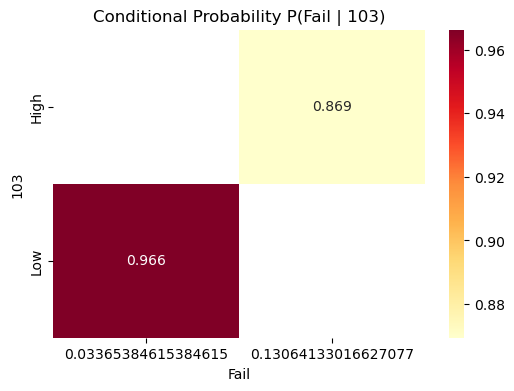

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Top Sensors by Mutual Information:
   Sensor        MI
10    316  0.025996
13     39  0.025151
18     59  0.012338
15    469  0.011475
0     103  0.008399
3     146  0.008305
11    319  0.005033
17    510  0.004341
6      21  0.003717
2     137  0.003528


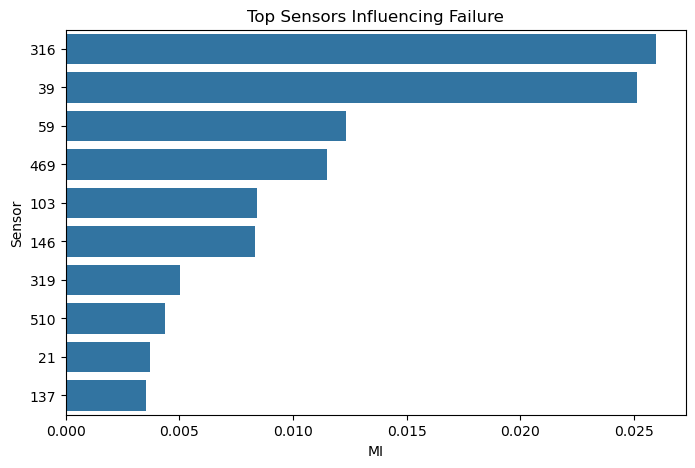

In [41]:
# IV. CPT Heatmap & Sensor Importance (Mutual Information)

import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Heatmap for CPT of Fail (example with parent 103)
cpt_fail = model.get_cpds("Fail")
cpt_df = cpt_fail.to_dataframe().reset_index()
pivot = cpt_df.pivot_table(values="Fail", index="103", columns="Fail")  # Adjust if more parents

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Conditional Probability P(Fail | 103)")
plt.show()

# Mutual Information – Sensor ranking
X_enc = X_train_discrete.copy()
for col in X_enc.columns:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col])

mi = mutual_info_classif(X_enc, y_train)
mi_df = pd.DataFrame({"Sensor": X_train_discrete.columns, "MI": mi}).sort_values("MI", ascending=False)

print("\nTop Sensors by Mutual Information:")
print(mi_df.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=mi_df.head(10), x="MI", y="Sensor")
plt.title("Top Sensors Influencing Failure")
plt.show()

**Key Insights - Sensor Importance via CPT & Mutual Information**
- **Heatmap CPT:** P(Fail | 103 = High) = 13.1% vs 3.4% when Low → Sensor 103 in High state strongly increases failure risk  
- **Top 10 Mutual Information (MI):** 316 (0.026), 39 (0.025), 59 (0.012), 469 (0.011), 103 (0.008) → these sensors most informative for Fail  
- MI highest in 316 and 39 → even if not direct parents of Fail in DAG, they provide strong indirect signals  
- Bar plot shows MI > 0.01 sensors are clearly more informative than the rest  

**Implications**
- **Sensor 103 is critical:** When High, P(Fail) rises sharply → engineers should prioritize monitoring/checking this sensor during Stage 1 alerts  
- **Top MI sensors (316, 39, 59…):** contain important indirect information → monitor to detect anomalies early  
- **Business value:** Focus maintenance/inspection on top 5–10 sensors → reduce failure risk, enabling **condition-based maintenance** instead of scheduled

In [42]:
# V. Root Cause Analysis - Example

print("\nP(103 | Fail = Fail)")
print(inference.query(variables=["103"], evidence={"Fail": "Fail"}))

print("\nP(103 | Fail = Pass)")
print(inference.query(variables=["103"], evidence={"Fail": "Pass"}))


P(103 | Fail = Fail)
+-----------+------------+
| 103       |   phi(103) |
+===========+============+
| 103(High) |     0.6627 |
+-----------+------------+
| 103(Low)  |     0.3373 |
+-----------+------------+

P(103 | Fail = Pass)
+-----------+------------+
| 103       |   phi(103) |
+===========+============+
| 103(High) |     0.3128 |
+-----------+------------+
| 103(Low)  |     0.6872 |
+-----------+------------+


**Key Insights – Sensor 103 Risk Uplift**
- **Conditional distribution:**  
  - Given Fail: P(103 = High) = 66.27% vs Low = 33.73% → High strongly associated with failure  
  - Given Pass: P(103 = Low) = 68.72% vs High = 31.28% → Low is safe/normal state  
- **Risk uplift:** P(103 = High | Fail) > 2 × P(103 = High | Pass) → Sensor 103 strongly discriminates Fail vs Pass

**Implications**
- **Sensor 103 is a critical indicator:** During Stage 1 alerts, high probability that 103 = High → prioritize checking this sensor first  
- **Protective state:** 103 = Low significantly reduces P(Fail) → operational guidance  
- **Business value:** Enables fast, specific RCA → reduces manual diagnostic time, downtime, and corrective costs  
- Supports **Dual-Monitoring System:** Stage 1 alert → Stage 2 queries P(sensor | Fail) → actionable recommendation ("check 103 due to High association with Fail")